# BEAD EDA

## Import Packages

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
      'text.usetex': True,
      'font.family': 'serif',
      'font.serif': ['Computer Modern Roman'],
      'font.size': 14,
  })
import seaborn as sns
import warnings
import scipy.stats as st
warnings.filterwarnings('ignore')

client = bigquery.Client(project="broadband-data")
print("Connected to BigQuery: broadband-data")

Connected to BigQuery: broadband-data


## Querying Bigquery for Data

In [2]:
# Peek at schemas before querying
for table in ['final_proposal.project_clean', 'final_proposal.location_clean', 'fcc_nbm.nbm_hive']:
    print(f"\n--- {table} ---")
    df_peek = client.query(f"SELECT * FROM `broadband-data.{table}` LIMIT 1").to_dataframe()
    print(list(df_peek.columns))


--- final_proposal.project_clean ---
['state', 'project_name', 'project_id', 'uei', 'project_description', 'project_type', 'priority_broadband_project', 'estimated_miles_aerial_fiber', 'estimated_miles_buried_fiber', 'estimated_jobs', 'estimated_subaward_date', 'estimated_performance_start', 'estimated_performance_end', 'intersect_tribal', 'tribal_consent_name', 'bead_support', 'fixed_amount_subaward', 'subgrantee_match', 'federal_match', 'state_match', 'other_match', 'federal_match_source', 'notes']

--- final_proposal.location_clean ---
['location_id', 'project_id', 'classification', 'technology', 'upload_speed_anticipated', 'download_speed_anticipated', 'low_latency', 'state']

--- fcc_nbm.nbm_hive ---
['frn', 'provider_id', 'brand_name', 'location_id', 'technology', 'max_advertised_download_speed', 'max_advertised_upload_speed', 'low_latency', 'business_residential_code', 'state_usps', 'block_geoid', 'h3_res8_id', 'release', 'period', 'state']


In [3]:
# Project-level data from fp_approved.deployment_projects
project_query = """
SELECT
    project_id,
    state,
    bead_support,
    estimated_miles_aerial_fiber,
    estimated_miles_buried_fiber,
    estimated_jobs,
    project_type,
    priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
"""
df_projects = client.query(project_query, location="US").to_dataframe()
print(f"Projects: {df_projects.shape}")
df_projects.head()

Projects: (5251, 8)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,project_type,priority_broadband_project
0,CM61-BEAD-SC-AECSC,SC,1065267.15,62.0,7.0,0.0,L,True
1,CM61-BEAD-SC-AMZSC,SC,5337600.00,0.0,0.0,11.0,L,False
2,CM61-BEAD-SC-ATTSC,SC,4209849.00,24.0,117.0,0.0,L,True
3,CM61-BEAD-SC-BRESC,SC,401004.00,5.0,4.0,12.0,L,True
4,CM61-BEAD-SC-BRISC,SC,10400.00,23.0,162.0,3.0,L,True


In [4]:
# Aggregate fp_approved.locations to project level
location_query = """
SELECT
    project_id,
    COUNT(*) AS funded_locations,
    MAX(SAFE_CAST(technology AS FLOAT64)) AS dominant_technology,
    AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
"""
df_locations = client.query(location_query).to_dataframe()
print(f"Location aggregates: {df_locations.shape}")
df_locations.head()

Location aggregates: (5228, 4)


,project_id,funded_locations,dominant_technology,avg_latency
0,CM61-BEAD-NM-51110179,85,70.0,1.0
1,CM61-BEAD-NM-51109127,4956,61.0,1.0
2,CM61-BEAD-NM-50066448,390,50.0,1.0
3,CM61-BEAD-NM-50066364,11920,72.0,1.0
4,CM61-BEAD-NM-51446572,1008,71.0,1.0


In [5]:
# state_num_providers from FCC NBM
# NBM uses full state names - map to 2-letter abbreviations to match project_clean
state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}

nbm_query = """
SELECT
    state,
    COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive`
GROUP BY state
"""
df_nbm = client.query(nbm_query).to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])
print(f"State provider counts: {df_nbm.shape}")
df_nbm.head()

State provider counts: (51, 2)


,state,state_num_providers
0,NE,128
1,WI,159
2,NM,96
3,VA,131
4,AZ,121


In [6]:
# Merge all three
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['dominant_technology'] = df['dominant_technology'].fillna(0)
df['avg_latency'] = df['avg_latency'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)

print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (5251, 12)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,project_type,priority_broadband_project,funded_locations,dominant_technology,avg_latency,state_num_providers
0,CM61-BEAD-SC-AECSC,SC,1065267.15,62.0,7.0,0.0,L,True,360,50.0,1.0,85
1,CM61-BEAD-SC-AMZSC,SC,5337600.00,0.0,0.0,11.0,L,False,8891,61.0,1.0,85
2,CM61-BEAD-SC-ATTSC,SC,4209849.00,24.0,117.0,0.0,L,True,758,50.0,1.0,85
3,CM61-BEAD-SC-BRESC,SC,401004.00,5.0,4.0,12.0,L,True,105,50.0,1.0,85
4,CM61-BEAD-SC-BRISC,SC,10400.00,23.0,162.0,3.0,L,True,89,50.0,1.0,85


In [7]:
# df.to_csv("bead.csv")

## EDA

In [8]:
df = pd.read_csv("bead.csv")

In [9]:
zero_rows = df[df['funded_locations'] == 0]

# Check if any rows were found
if not zero_rows.empty:
    print("Found rows with 0 funded locations!")
    print(zero_rows)

Found rows with 0 funded locations!
      Unnamed: 0                 project_id state  bead_support  \
4              4      CM61-BEAD-OK-270-3783    OK  2.800000e+03   
16            16      CM61-BEAD-OK-270-3780    OK  4.194000e+03   
33            33      CM61-BEAD-OK-301-2687    OK  4.179398e+03   
49            49      CM61-BEAD-OK-270-2841    OK  7.040000e+02   
62            62      CM61-BEAD-OK-270-3779    OK  3.500000e+03   
75            75       CM61-BEAD-OK-93-2439    OK  1.600000e+00   
1291        1291          CM61-BEAD-MT-4678    MT  3.312400e+04   
1700        1700            CSD- BEAD - 200    SD  5.450756e+07   
1701        1701            CSD -BEAD - 100    SD  1.287378e+07   
1702        1702            CSD -BEAD - 300    SD  3.838725e+06   
1703        1703            CSD -BEAD - 400    SD  1.596000e+06   
1705        1705        CM61-BEAD-WV-482635    WV  1.020402e+04   
1707        1707        CM61-BEAD-WV-482312    WV  2.326921e+04   
1725        1725        CM

### Visualizations

Characterize the target (`funding_per_location`) and its drivers before modeling. Each cell builds a local `eda` frame so it runs independently.

**Viz 1 - Target distributions.** Histograms of `bead_support` and `funding_per_location`, raw vs `log1p`. Both are heavily right-skewed raw. Using a log transform makes them roughly symmetric 

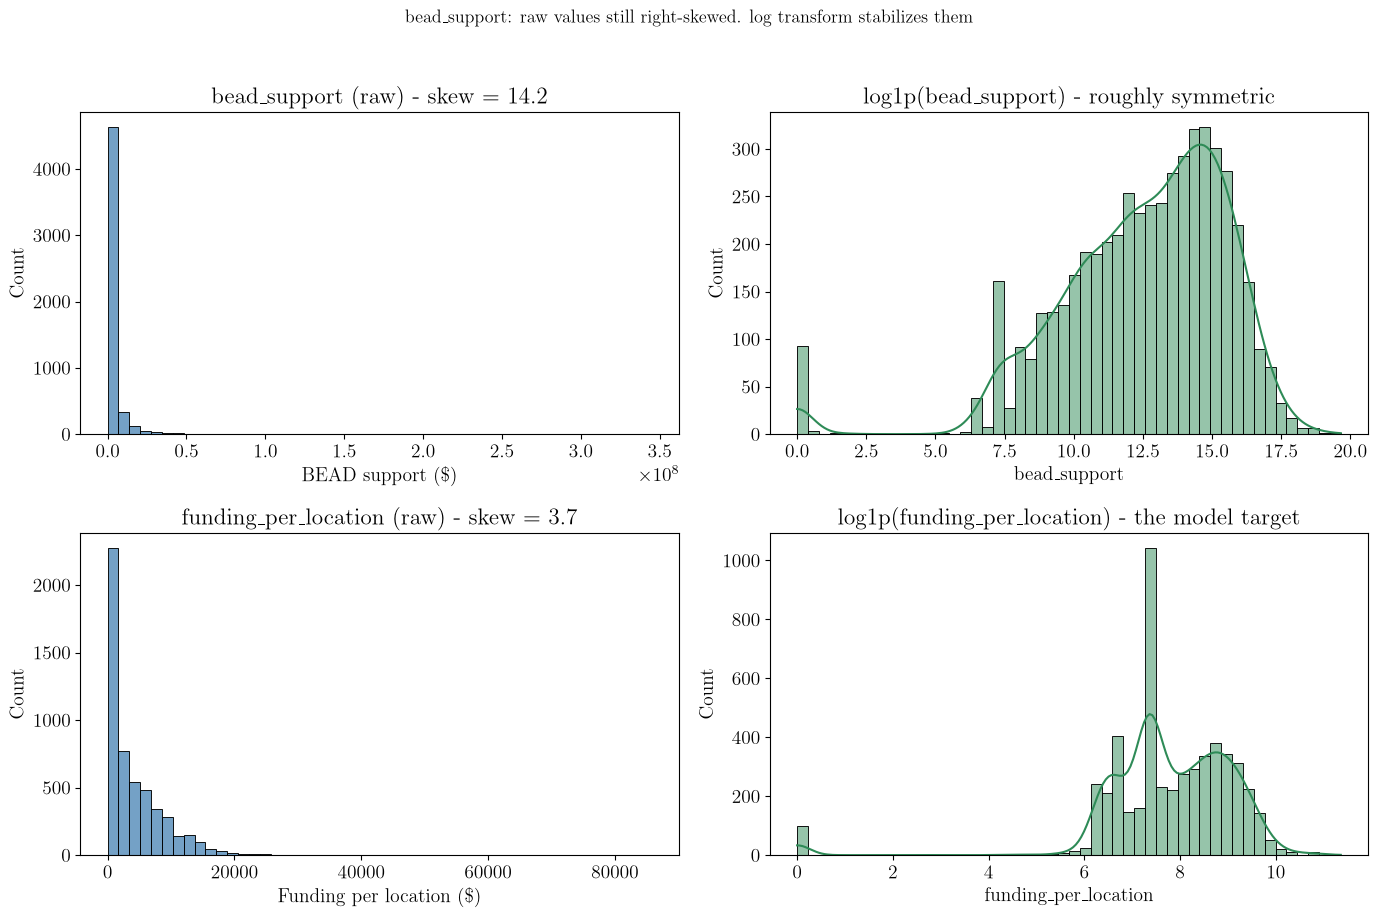

In [10]:
# Viz 1 why the target gets a log transform
eda = df.copy()
if 'funding_per_location' not in eda.columns:
    eda['funding_per_location'] = eda['bead_support'] / eda['funded_locations'].replace(0, np.nan)
eda = eda.dropna(subset=['funding_per_location'])


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(eda['bead_support'], bins=50, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title(f"bead_support (raw) - skew = {eda['bead_support'].skew():.1f}")
axes[0, 0].set_xlabel('BEAD support (\$)')

sns.histplot(np.log1p(eda['bead_support']), bins=50, kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('log1p(bead_support) - roughly symmetric')

sns.histplot(eda['funding_per_location'], bins=50, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title(f"funding_per_location (raw) - skew = {eda['funding_per_location'].skew():.1f}")
axes[1, 0].set_xlabel('Funding per location (\$)')

sns.histplot(np.log1p(eda['funding_per_location']), bins=50, kde=True, ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('log1p(funding_per_location) - the model target')

plt.suptitle('bead_support: raw values still right-skewed. log transform stabilizes them', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('plots/viz_1_eda_distributions.png', dpi=600, bbox_inches='tight')
plt.show()

**Viz 2 - Cost by categorical drivers.** Box plots of `funding_per_location` (log y) split by the priority-project flag, showing how per-location cost shifts across these categories.

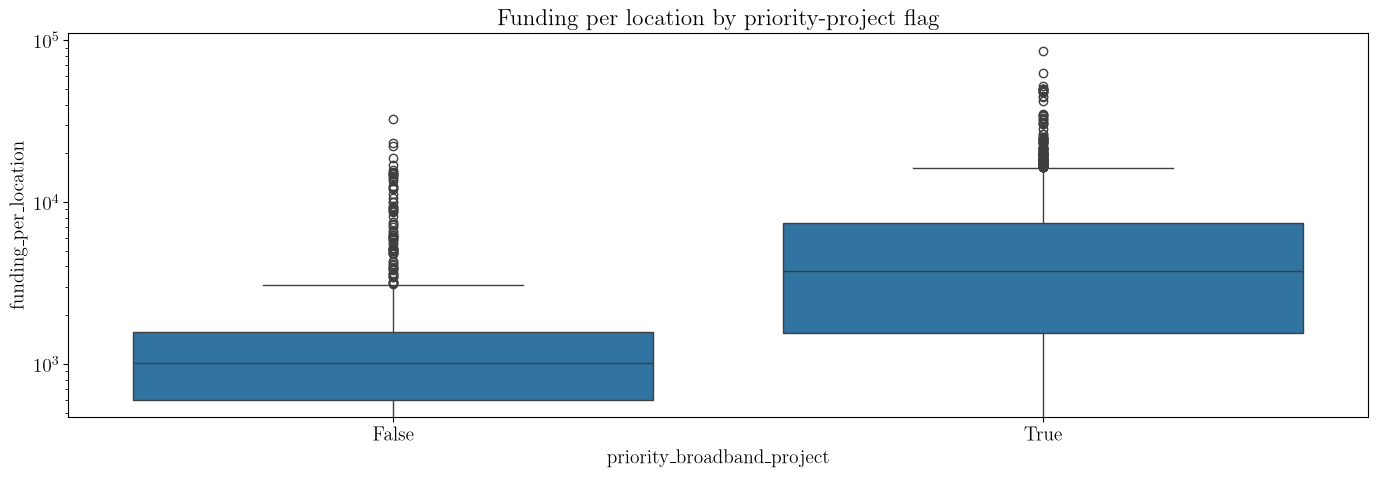

In [11]:
# Viz 2 - Target by categorical drivers (log y-axis so the skew doesn't hide the boxes)
plt.figure(figsize=(14, 5))

sns.boxplot(data=eda, x='priority_broadband_project', y='funding_per_location')
plt.yscale('log')
plt.title('Funding per location by priority-project flag')
plt.xlabel('priority_broadband_project')

plt.tight_layout()
plt.savefig('plots/viz_2_eda_categorical.png', dpi=600)
plt.show()

**Viz 2b - What kinds of projects are "priority"?** `project_type` is ~99\% one category, so the meaningful split is by **dominant technology**. Left: the technology mix within priority projects. Right: priority vs non-priority composition - priority projects are overwhelmingly **fiber** (64\%), while non-priority skew to **satellite** (79\%).

In [ ]:
# Viz 2b - Technology mix of priority projects (and priority vs non-priority)
tech_labels = {0:'Unknown',10:'DSL',40:'Coax/HFC',50:'Fiber',60:'GSO Sat',
               61:'NGSO Sat',70:'Unlic FW',71:'Lic FW',72:'LBR FW'}
p = df.copy()
p['tech'] = p['dominant_technology'].map(tech_labels).fillna('Other')
p['grp'] = np.where(p['priority_broadband_project'] == True, 'Priority', 'Non-priority')

order = p[p['grp']=='Priority']['tech'].value_counts().index.tolist()
share = (p.groupby('grp')['tech'].value_counts(normalize=True)*100).unstack().reindex(columns=order).fillna(0)
pc = p[p['grp']=='Priority']['tech'].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Left: counts within priority projects
axes[0].barh(order[::-1], pc.reindex(order[::-1]).values, color='seagreen')
for i, v in enumerate(pc.reindex(order[::-1]).values):
    axes[0].text(v, i, rf' {v:,} ({v/pc.sum()*100:.0f}\%)', va='center')
axes[0].set_xlabel('Number of priority projects')
axes[0].set_title('Technology mix of priority projects')

# Right: share comparison, priority vs non-priority
x = np.arange(len(order)); w = 0.38
axes[1].bar(x-w/2, share.loc['Priority', order].values, w, label='Priority', color='seagreen')
axes[1].bar(x+w/2, share.loc['Non-priority', order].values, w, label='Non-priority', color='indianred')
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=25, ha='right')
axes[1].set_ylabel(r'\% of group')
axes[1].set_title('Priority vs non-priority composition')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/viz_2b_priority_project_types.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 3 - Correlation matrix.** Pearson correlations among the numeric features and the target.

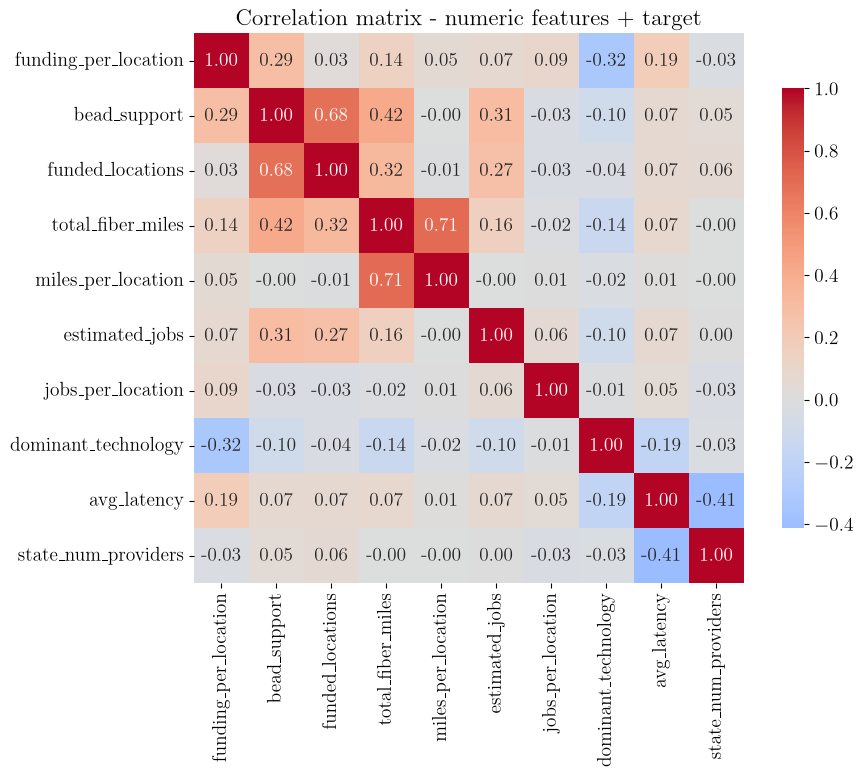

In [12]:
# Viz 3 - Correlation among numeric features and the target
eda['total_fiber_miles'] = eda['estimated_miles_aerial_fiber'].fillna(0) + eda['estimated_miles_buried_fiber'].fillna(0)
eda['miles_per_location'] = eda['total_fiber_miles'] / eda['funded_locations'].replace(0, np.nan)
eda['jobs_per_location']  = eda['estimated_jobs'] / eda['funded_locations'].replace(0, np.nan)

num_cols = ['funding_per_location', 'bead_support', 'funded_locations', 'total_fiber_miles',
            'miles_per_location', 'estimated_jobs', 'jobs_per_location',
            'dominant_technology', 'avg_latency', 'state_num_providers']
corr = eda[num_cols].fillna(0).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix - numeric features + target')
plt.tight_layout()
plt.savefig('plots/viz_3_eda_corr.png', dpi=600)
plt.show()

**Viz 4 - Cost by state.** Mean `funding_per_location` per state (bootstrap 95% CIs on mean) (states with $\ge$ 5 projects), sorted high to low. 

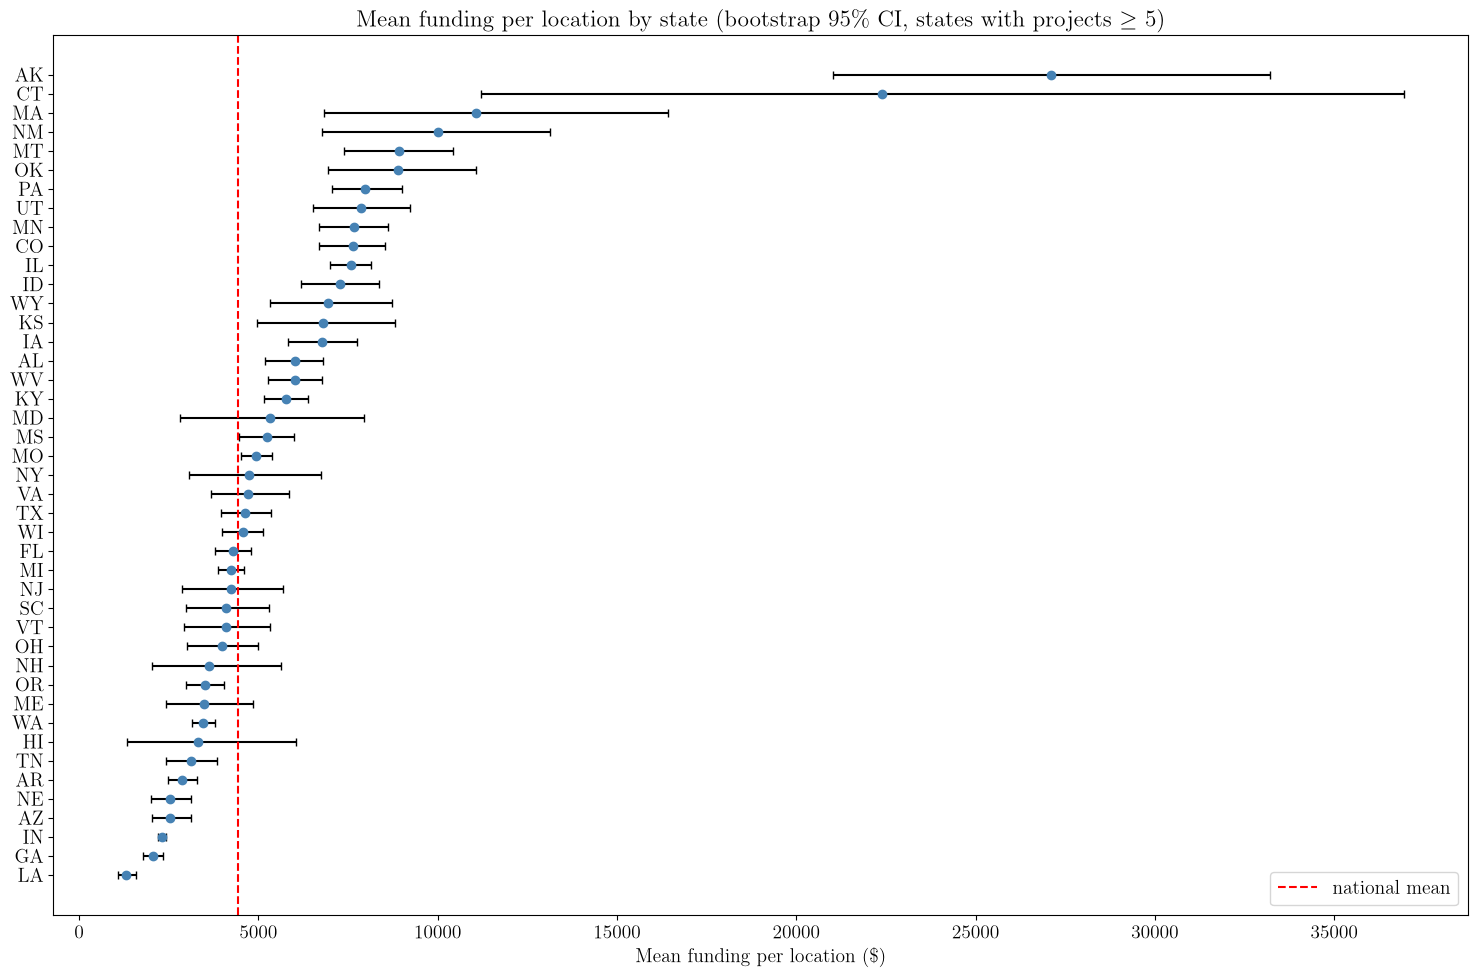

In [13]:
# Viz 4 - Mean funding per location by state (bootstrap 95% CI on the mean)
# Bootstrap makes no normality assumption, so it handles the heavy right skew
rng = np.random.default_rng(42)
B = 2000

def boot_mean_ci(vals, n_boot=B, alpha=0.05):
    vals = np.asarray(vals)
    means = rng.choice(vals, size=(n_boot, len(vals)), replace=True).mean(axis=1)
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return vals.mean(), lo, hi

rows = []
for state, g in eda.groupby('state')['funding_per_location']:
    if len(g) >= 5:
        m, lo, hi = boot_mean_ci(g.values)
        rows.append((state, m, lo, hi, len(g)))
state_stats = (pd.DataFrame(rows, columns=['state', 'mean', 'lo', 'hi', 'count'])
                 .set_index('state').sort_values('mean', ascending=False))

# asymmetric error bars: distance from the mean to each CI bound
xerr = np.vstack([state_stats['mean'] - state_stats['lo'],
                  state_stats['hi'] - state_stats['mean']])

plt.figure(figsize=(15, 10))
plt.errorbar(state_stats['mean'], range(len(state_stats)), xerr=xerr,
             fmt='o', color='steelblue', ecolor='black', capsize=3)
plt.yticks(range(len(state_stats)), state_stats.index)
plt.gca().invert_yaxis()
plt.axvline(eda['funding_per_location'].mean(), color='red', linestyle='--', label='national mean')
plt.xlabel(r'Mean funding per location (\$)')
plt.legend()
plt.title(r'Mean funding per location by state  (bootstrap 95\% CI, states with projects $\ge$ 5)')
plt.tight_layout()
plt.savefig('plots/viz_4a_eda_state', dpi=600)
plt.show()

**Viz 4b - Project count by state.** Number of funded projects per state, ordered by frequency.

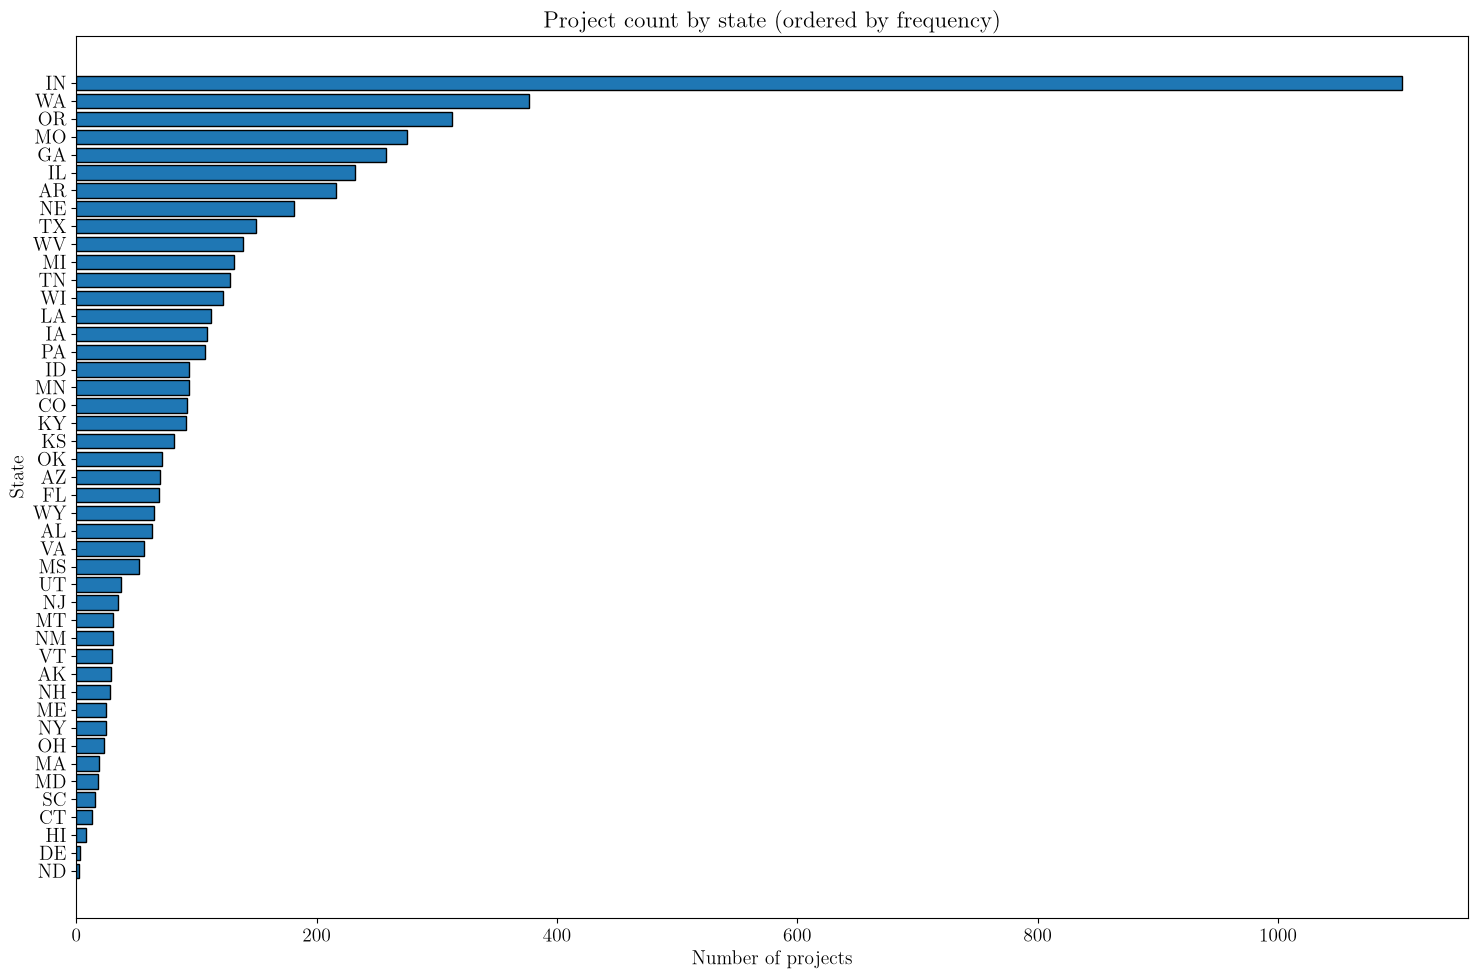

In [14]:
state_counts = eda['state'].value_counts().sort_values()

plt.figure(figsize=(15, 10))
plt.barh(state_counts.index, state_counts.values, edgecolor='black')
plt.xlabel('Number of projects')
plt.ylabel('State')
plt.title('Project count by state (ordered by frequency)')
plt.tight_layout()
plt.savefig('plots/viz_4b_eda_state_count', dpi=600)
plt.show()

**Viz 5 - feature vs. target.** Log-scaled scatters of `funding_per_location` against its two strongest physical drivers.

- **Funded locations (log-log):** cost per location *rises* slightly with size - no economies of scale.
- **Fiber miles per location:** strongly positive and monotone. Linear corr looks tiny only because the trend is nonlinear. x clipped at the 99th pct.

Build intensity and scale carry real, nonlinear signal (ideal for a random forest).

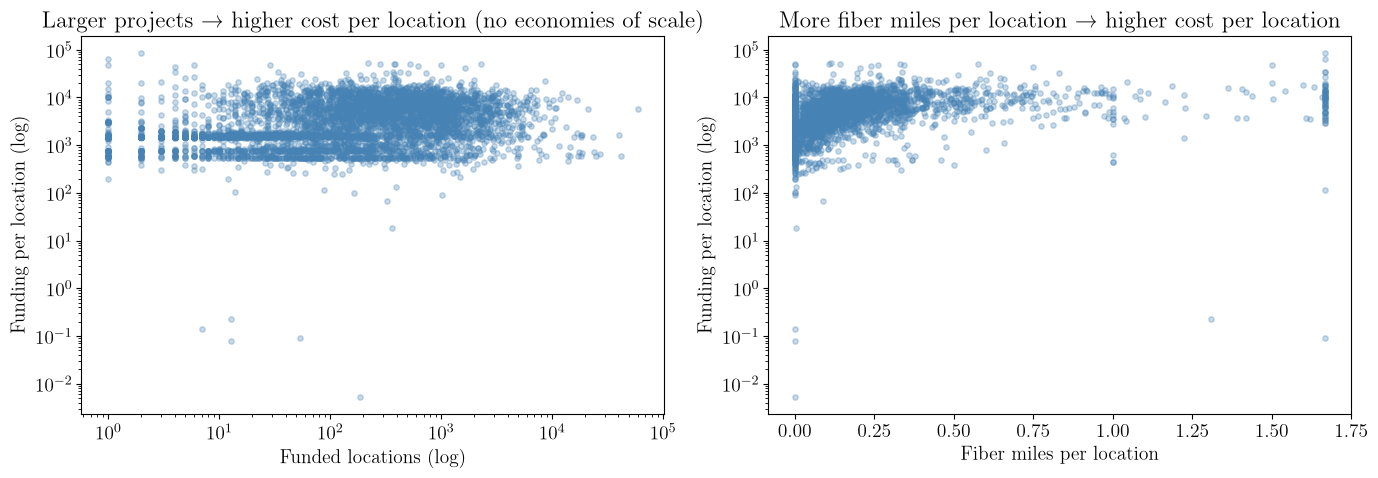

In [15]:
# Viz 5 - Key feature vs target relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(eda['funded_locations'], eda['funding_per_location'],
                alpha=0.3, s=15, color='steelblue')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Funded locations (log)')
axes[0].set_ylabel('Funding per location (log)')
axes[0].set_title('Larger projects → higher cost per location (no economies of scale)')

mpl = eda['miles_per_location'].clip(upper=eda['miles_per_location'].quantile(0.99))
axes[1].scatter(mpl, eda['funding_per_location'], alpha=0.3, s=15, color='steelblue')
axes[1].set_yscale('log')
axes[1].set_xlabel('Fiber miles per location')
axes[1].set_ylabel('Funding per location (log)')
axes[1].set_title('More fiber miles per location → higher cost per location')

plt.tight_layout()
plt.savefig('plots/viz_5_eda_scatter.png', dpi=600)
plt.show()

**Viz 6 - BEAD support vs fiber miles.** Log-log scatter of total funding against total fiber miles, colored by aerial vs buried-dominant. The aerial/buried split shows little separation.

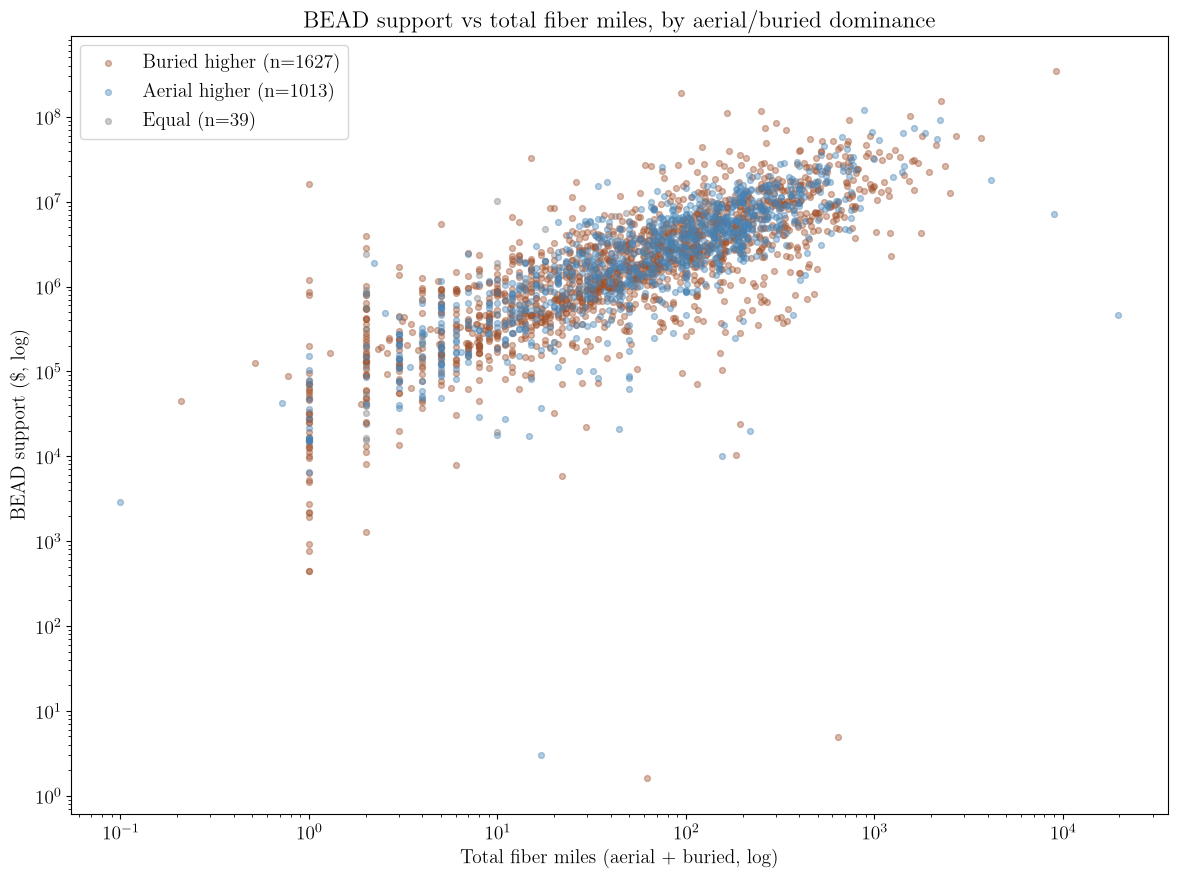

In [16]:
# Viz 6 - BEAD support vs total fiber miles, colored by aerial vs buried dominance
sc = df.copy()
sc['total_fiber_miles'] = sc['estimated_miles_aerial_fiber'].fillna(0) + sc['estimated_miles_buried_fiber'].fillna(0)
sc = sc[(sc['total_fiber_miles'] > 0) & (sc['bead_support'] > 0)]

aerial = sc['estimated_miles_aerial_fiber'].fillna(0)
buried = sc['estimated_miles_buried_fiber'].fillna(0)
sc['fiber_mix'] = np.where(buried > aerial, 'Buried higher',
                  np.where(aerial > buried, 'Aerial higher', 'Equal'))

colors = {'Buried higher': 'sienna', 'Aerial higher': 'steelblue', 'Equal': 'gray'}

plt.figure(figsize=(12, 9))
for label, color in colors.items():
    grp = sc[sc['fiber_mix'] == label]
    plt.scatter(grp['total_fiber_miles'], grp['bead_support'],
                alpha=0.4, s=18, color=color, label=f'{label} (n={len(grp)})')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('Total fiber miles (aerial + buried, log)')
plt.ylabel('BEAD support (\$, log)')
plt.title('BEAD support vs total fiber miles, by aerial/buried dominance')
plt.legend()
plt.tight_layout()
plt.savefig('plots/viz_6_eda_fiber_mix_scatter.png', dpi=600)
plt.show()


In [17]:
df['dominant_technology'].value_counts()
# sometimes locations have state and federal funds to make them broadband accessible

dominant_technology
50.0    2593
61.0    1840
71.0     528
72.0     186
40.0      44
0.0       30
70.0      28
60.0       2
Name: count, dtype: int64

**Viz 7 - Cost by technology.** Box plots of BEAD support per project by dominant technology (log y), ordered by median. Wireline (fiber/coax) sits well above wireless/satellite.

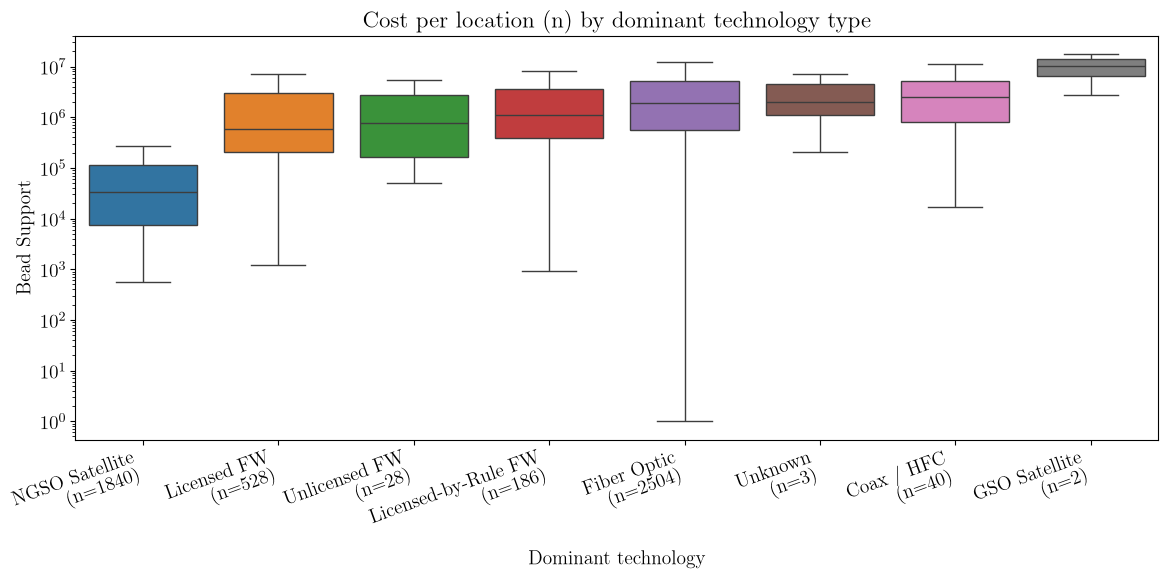

In [18]:
# Viz 7 - Cost (funding per location) by dominant technology type, color-coded by technology
tech = df.copy()
tech['funding_per_location'] = tech['bead_support'] / tech['funded_locations'].replace(0, np.nan)
tech = tech.dropna(subset=['funding_per_location'])
tech = tech[tech['funding_per_location'] > 0]

# FCC BDC technology codes -> human-readable labels
tech_labels = {
    0:  'Unknown',
    10: 'Digital Subscriber Line ',
    40: 'Coax / HFC',
    50: 'Fiber Optic',
    60: 'GSO Satellite',
    61: 'NGSO Satellite',
    70: 'Unlicensed FW',
    71: 'Licensed FW',
    72: 'Licensed-by-Rule FW',
}
tech['tech_name'] = tech['dominant_technology'].map(tech_labels).fillna('Other')

# Order categories by median cost so the plot reads left-to-right
order = (tech.groupby('tech_name')['bead_support'].median()
             .sort_values().index.tolist())
palette = dict(zip(order, sns.color_palette('tab10', len(order))))

plt.figure(figsize=(12, 6))
sns.boxplot(data=tech, x='tech_name', y='bead_support',
            order=order, palette=palette, showfliers=False)
counts = tech['tech_name'].value_counts()
plt.xticks(range(len(order)), [f'{t}\n(n={counts[t]})' for t in order], rotation=20, ha='right')
plt.yscale('log')
plt.xlabel('Dominant technology')
plt.ylabel('Bead Support')
plt.title('Cost per location (n) by dominant technology type')
plt.tight_layout()
plt.savefig('plots/viz_7_eda_cost_by_technology.png', dpi=600)
plt.show()


**Viz 7b - Fiber vs others.** Box plots of BEAD support per project, grouping fiber optic against all other technologies combined (log y). Fiber sits far above everything else.

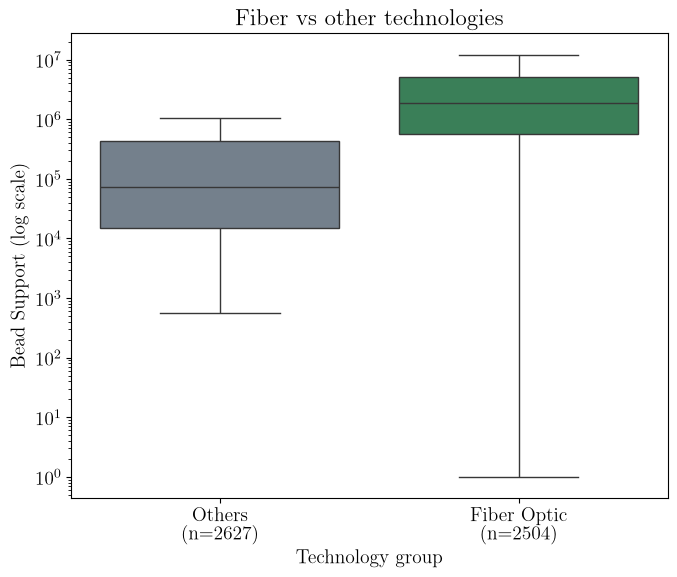

In [19]:
# Viz 7b - Fiber vs all other technologies (BEAD support per project)
techb = df.copy()
techb['funding_per_location'] = techb['bead_support'] / techb['funded_locations'].replace(0, np.nan)
techb = techb.dropna(subset=['funding_per_location'])
techb = techb[techb['funding_per_location'] > 0]

techb['fiber_group'] = np.where(techb['dominant_technology'] == 50, 'Fiber Optic', 'Others')

order = ['Others', 'Fiber Optic']
palette = {'Fiber Optic': 'seagreen', 'Others': 'slategray'}

plt.figure(figsize=(7, 6))
sns.boxplot(data=techb, x='fiber_group', y='bead_support',
            order=order, palette=palette, showfliers=False)
counts = techb['fiber_group'].value_counts()
plt.xticks(range(len(order)), [f'{g}\n(n={counts[g]})' for g in order])
plt.yscale('log')
plt.xlabel('Technology group')
plt.ylabel('Bead Support (log scale)')
plt.title('Fiber vs other technologies')
plt.tight_layout()
plt.savefig('plots/viz_7b_fiber_vs_others.png', dpi=600)
plt.show()

In [20]:

# df.query("dominant_technology == 0")
df.loc[df['dominant_technology'] == 0, ['project_id', 'bead_support','funded_locations']]

,project_id,bead_support,funded_locations
4,CM61-BEAD-OK-270-3783,2.800000e+03,0
16,CM61-BEAD-OK-270-3780,4.194000e+03,0
33,CM61-BEAD-OK-301-2687,4.179398e+03,0
49,CM61-BEAD-OK-270-2841,7.040000e+02,0
62,CM61-BEAD-OK-270-3779,3.500000e+03,0
75,CM61-BEAD-OK-93-2439,1.600000e+00,0
1129,CM61-BEAD-AZ-44-530,6.994619e+06,409
1291,CM61-BEAD-MT-4678,3.312400e+04,0
1700,CSD- BEAD - 200,5.450756e+07,0
1701,CSD -BEAD - 100,1.287378e+07,0


**Viz 8 - QQ plots (normality check).** Raw vs `log1p` of `bead_support` and `funding_per_location` against a normal reference line. Raw values bow off the line (heavy right tail); the logged versions track it closely, justifying the log target.

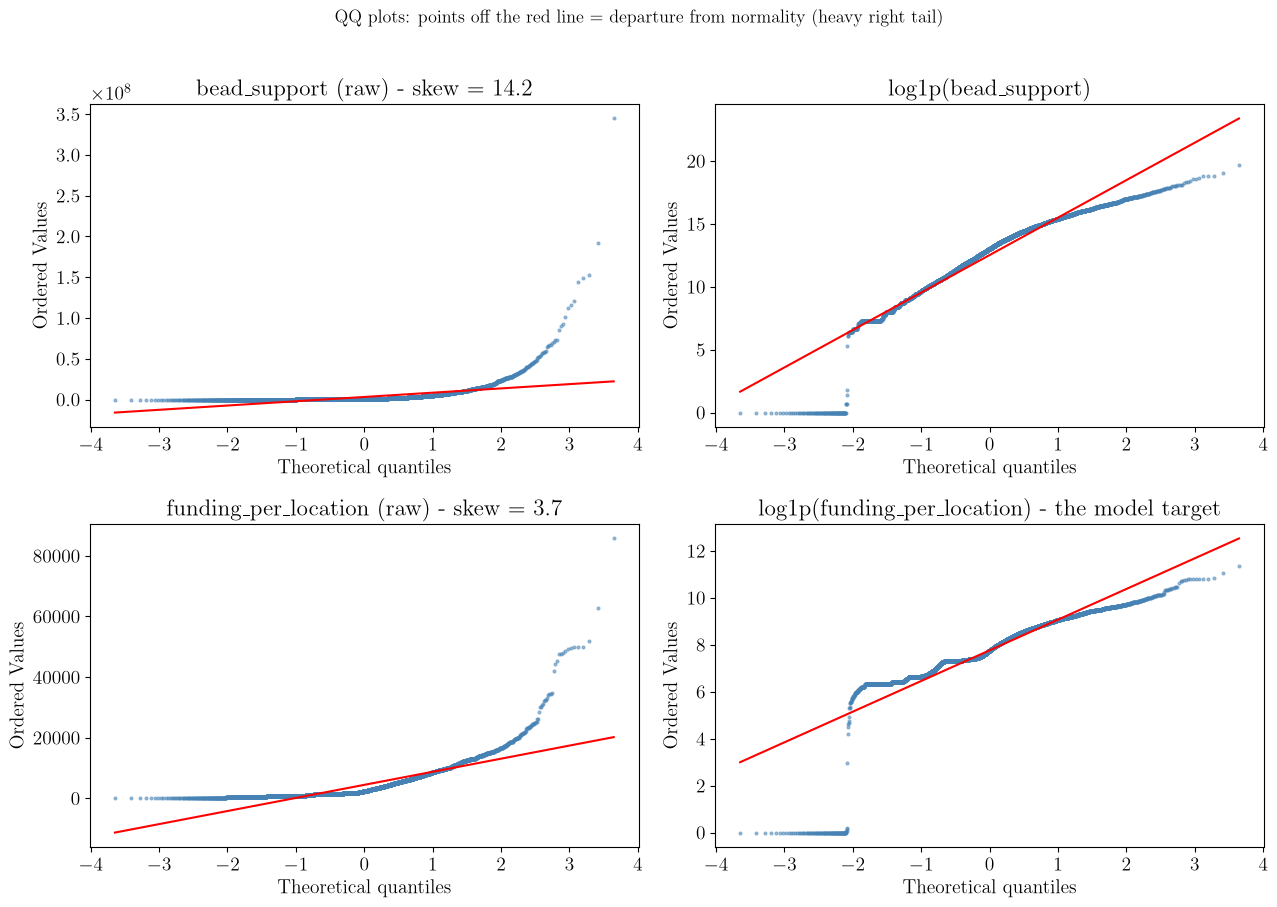

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

st.probplot(eda['bead_support'], dist='norm', plot=axes[0, 0])
axes[0, 0].set_title(f"bead_support (raw) - skew = {eda['bead_support'].skew():.1f}")

st.probplot(np.log1p(eda['bead_support']), dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('log1p(bead_support)')

st.probplot(eda['funding_per_location'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title(f"funding_per_location (raw) - skew = {eda['funding_per_location'].skew():.1f}")

st.probplot(np.log1p(eda['funding_per_location']), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('log1p(funding_per_location) - the model target')

# Recolor the scatter (probplot defaults to blue dots + red fit line)
for ax in axes.ravel():
    ax.get_lines()[0].set(marker='.', markersize=4, color='steelblue', alpha=0.5)
    ax.get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle('QQ plots: points off the red line = departure from normality (heavy right tail)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('plots/viz_8_eda_qqplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Allocation vs Bids Scatterplot

In [22]:
deployed_projects_query = """
SELECT
    project_id,
    project_name,
    bead_support as deployed_project_bead_support,
FROM `broadband-data.fp_approved.deployment_projects`
"""

project_query = """
SELECT
    project_id,
    project_name,
    bead_support as final_proposal_bead_support,
FROM `broadband-data.final_proposal.project_clean`
"""

df_project = client.query(project_query).to_dataframe()
df_deployed = client.query(deployed_projects_query).to_dataframe()
alloted_df = df_project.merge(df_deployed, on='project_id', how='left')

**Deployed vs proposed funding.** For projects accepted into the final proposal, deployed funding vs the proposed amount (log-log, with the y = x line). Almost all points sit on the line - once accepted, the amount rarely changes.

Accepted pairs: 4345  |  amount unchanged from proposal: 86.8%


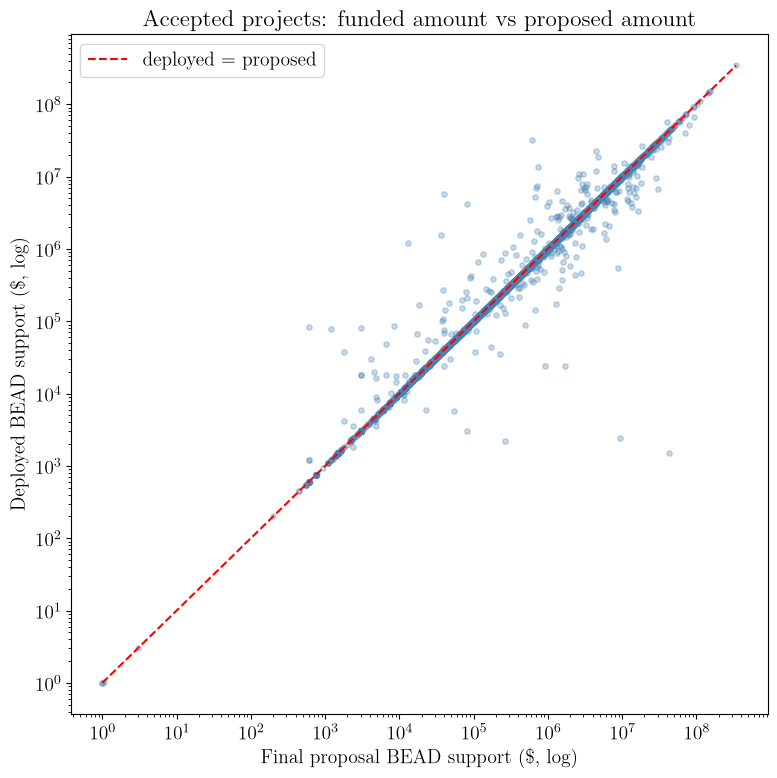

In [23]:
# Among ACCEPTED (deployed) projects: does the funded amount differ from the proposal?
# Viz 9
pair = alloted_df.dropna(subset=['deployed_project_bead_support']).copy()
pair = pair[(pair['final_proposal_bead_support'] > 0) &
            (pair['deployed_project_bead_support'] > 0)]
unchanged = (pair['final_proposal_bead_support'] == pair['deployed_project_bead_support']).mean()
print(f"Accepted pairs: {len(pair)}  |  amount unchanged from proposal: {unchanged:.1%}")

x = pair['final_proposal_bead_support']
y = pair['deployed_project_bead_support']

plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.3, s=15, color='steelblue')
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, 'r--', label='deployed = proposed')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Final proposal BEAD support (\$, log)')
plt.ylabel(r'Deployed BEAD support (\$, log)')
plt.title('Accepted projects: funded amount vs proposed amount')
plt.legend()
plt.tight_layout()
plt.savefig('plots/viz_9_funded_vs_proposed.png', dpi=600, bbox_inches='tight')
plt.show()

**Viz 9b - Funded vs proposed, central 95%.** Same as Viz 9 but clipped to the central 95% of BEAD support (drop the extreme 2.5% tails on both axes), keeping the log-log scale for consistency with Viz 9.

Central 95% clip: 4173 of 4345 pairs kept (96.0%)


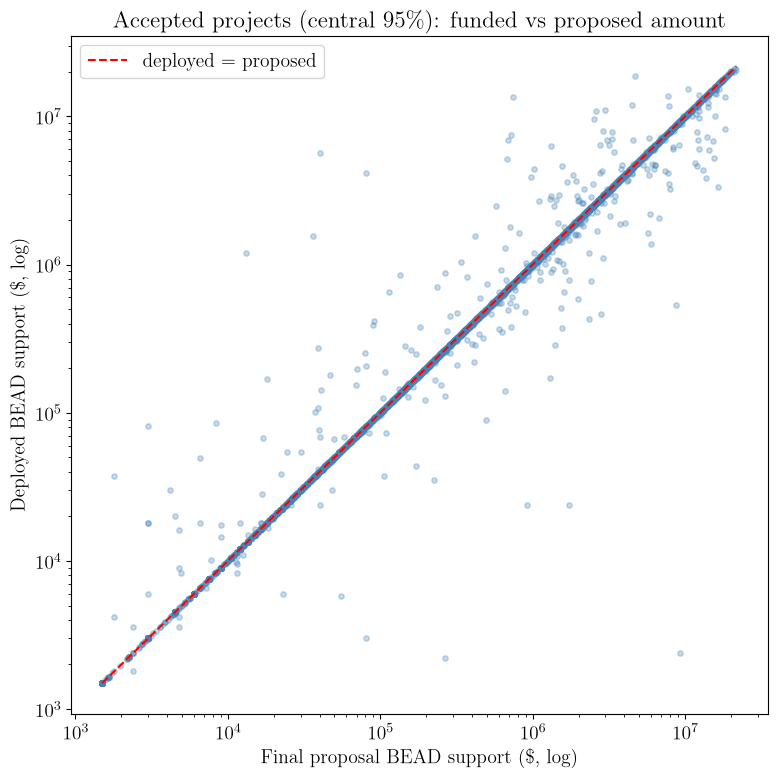

In [24]:
# Viz 9b - Viz 9 clipped to the central 95% of BEAD support (log scale, consistent with Viz 9)
# Drop the extreme 2.5% tails on BOTH axes so the bulk of accepted projects is visible.
xlo, xhi = pair['final_proposal_bead_support'].quantile([0.025, 0.975])
ylo, yhi = pair['deployed_project_bead_support'].quantile([0.025, 0.975])
clip = pair[pair['final_proposal_bead_support'].between(xlo, xhi) &
            pair['deployed_project_bead_support'].between(ylo, yhi)]
print(f"Central 95% clip: {len(clip)} of {len(pair)} pairs kept ({len(clip)/len(pair):.1%})")

x = clip['final_proposal_bead_support']
y = clip['deployed_project_bead_support']

plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.3, s=15, color='steelblue')
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, 'r--', label='deployed = proposed')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Final proposal BEAD support (\$, log)')
plt.ylabel(r'Deployed BEAD support (\$, log)')
plt.title('Accepted projects (central 95\%): funded vs proposed amount')
plt.legend()
plt.tight_layout()
plt.savefig('plots/viz_9b_funded_vs_proposed_clipped.png', dpi=600, bbox_inches='tight')
plt.show()

**What predicts acceptance?** Since the amount barely changes once accepted, the real question is *which* proposals get accepted. Left: proposal-size distribution for accepted vs not; right: the same as box plots. Accepted proposals are markedly larger.

Accepted: 4345  (median proposal $482,061)
Not accepted: 2062  (median proposal $58,740)


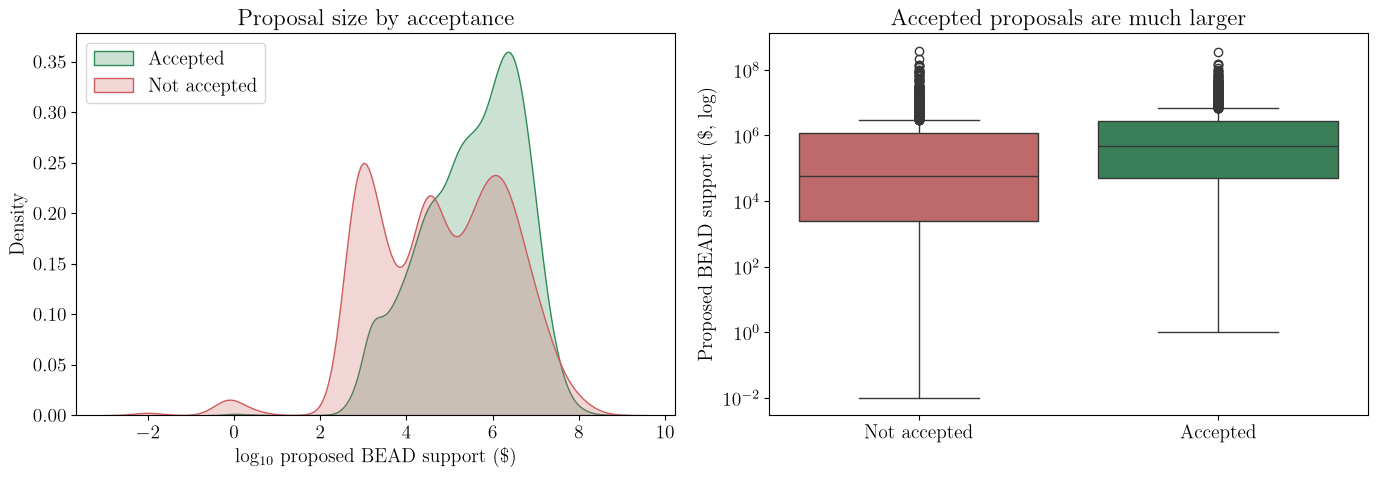

In [25]:
# The real question: does proposal SIZE predict acceptance (deployment)?
# "Accepted" = has a deployed_project_bead_support (passed final-proposal review).
sel = alloted_df[alloted_df['final_proposal_bead_support'] > 0].copy()
sel['accepted'] = sel['deployed_project_bead_support'].notna()
sel['status'] = sel['accepted'].map({True: 'Accepted', False: 'Not accepted'})
sel['log_proposal'] = np.log10(sel['final_proposal_bead_support'])

acc = sel[sel['accepted']]
rej = sel[~sel['accepted']]
print(f"Accepted: {len(acc)}  (median proposal ${acc['final_proposal_bead_support'].median():,.0f})")
print(f"Not accepted: {len(rej)}  (median proposal ${rej['final_proposal_bead_support'].median():,.0f})")

pal = {'Accepted': 'seagreen', 'Not accepted': 'indianred'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=acc, x='log_proposal', fill=True, color='seagreen', label='Accepted', ax=axes[0])
sns.kdeplot(data=rej, x='log_proposal', fill=True, color='indianred', label='Not accepted', ax=axes[0])
axes[0].set_xlabel(r'log$_{10}$ proposed BEAD support (\$)')
axes[0].set_title('Proposal size by acceptance')
axes[0].legend()

sns.boxplot(data=sel, x='status', y='final_proposal_bead_support',
            hue='status', order=['Not accepted', 'Accepted'],
            palette=pal, legend=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('')
axes[1].set_ylabel(r'Proposed BEAD support (\$, log)')
axes[1].set_title('Accepted proposals are much larger')
plt.tight_layout()
plt.show()

In [26]:
# Provider landscape from broadband-data.fcc_nbm.provider_count_county_level
# A few simple context graphs on who provides broadband, by technology / brand / state.
# pc_table = "broadband-data.fcc_bdc.provider_coverage_state_level"

# tech = client.query(f"""
#     SELECT technology, COUNT(DISTINCT provider_id) AS providers
#     FROM `{pc_table}` GROUP BY technology ORDER BY providers DESC
# """).to_dataframe()
# brands = client.query(f"""
#     SELECT brand_name, COUNT(DISTINCT county_geoid) AS counties
#     FROM `{pc_table}` GROUP BY brand_name ORDER BY counties DESC LIMIT 15
# """).to_dataframe()
# states = client.query(f"""
#     SELECT state, COUNT(DISTINCT provider_id) AS providers
#     FROM `{pc_table}` GROUP BY state ORDER BY providers DESC LIMIT 15
# """).to_dataframe()

# ----- NEW: broadband-data.fcc_bdc.provider_coverage_state_level -----
# Per-state, per-provider coverage (served locations + nested technology breakdown).
cov_table = "broadband-data.fcc_bdc.provider_coverage_state_level"

brand_cov = client.query(f"""
    SELECT brand_name, SUM(served_locations) AS served
    FROM `{cov_table}` GROUP BY brand_name ORDER BY served DESC LIMIT 15
""").to_dataframe()
state_prov = client.query(f"""
    SELECT state, COUNT(DISTINCT provider_id) AS providers
    FROM `{cov_table}` GROUP BY state ORDER BY providers DESC LIMIT 15
""").to_dataframe()
tech_cov = client.query(f"""
    SELECT tb.technology AS technology, SUM(tb.tech_locations) AS locations
    FROM `{cov_table}`, UNNEST(tech_breakdown) AS tb
    GROUP BY technology ORDER BY locations DESC
""").to_dataframe()


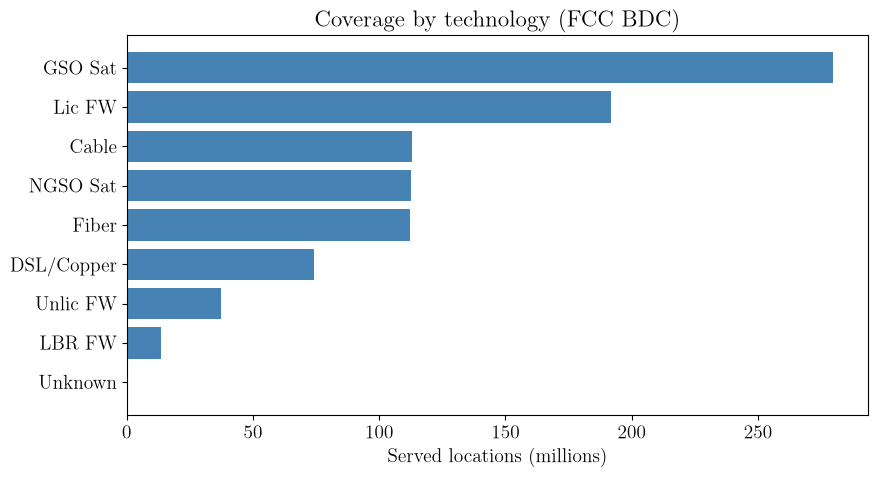

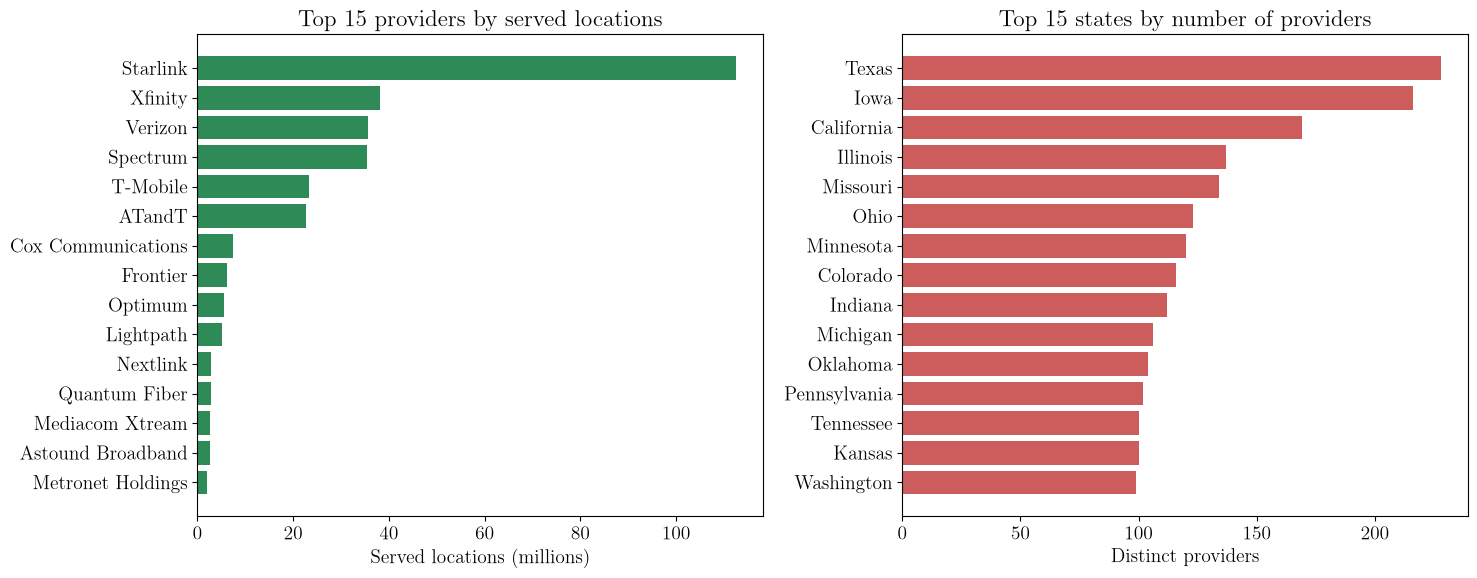

In [27]:


# # usetex is on for this notebook, so strip characters LaTeX chokes on (& and _)
# def safe(s):
#     return str(s).replace('&', 'and').replace('_', ' ')

# tech_labels = {0:'Unknown', 10:'DSL/Copper', 40:'Cable', 50:'Fiber', 60:'GSO Sat',
#                61:'NGSO Sat', 70:'Unlic FW', 71:'Lic FW', 72:'LBR FW'}
# tech['label'] = tech['technology'].map(tech_labels).fillna('Other')
# tech = tech.sort_values('providers')

# # Graph 1: number of distinct providers by technology
# plt.figure(figsize=(9, 5))
# plt.barh(tech['label'], tech['providers'], color='steelblue')
# plt.xlabel('Distinct providers')
# plt.title('Broadband providers by technology')
# plt.tight_layout()
# # plt.savefig('provider_by_technology.png', dpi=150)
# plt.show()


# # Graph 2 & 3: top brands by county reach, and providers per state
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# b = brands.sort_values('counties')
# axes[0].barh([safe(x) for x in b['brand_name']], b['counties'], color='seagreen')
# axes[0].set_xlabel('Counties served')
# axes[0].set_title('Top 15 providers by county reach')

# s = states.sort_values('providers')
# axes[1].barh([safe(x) for x in s['state']], s['providers'], color='indianred')
# axes[1].set_xlabel('Distinct providers')
# axes[1].set_title('Top 15 states by number of providers')

# plt.tight_layout() 
# # plt.savefig('provider_reach_by_brand_state.png', dpi=150)

# plt.show()




# ----- NEW: broadband-data.fcc_bdc.provider_coverage_state_level -----
# Per-state, per-provider coverage (served locations + nested technology breakdown).
cov_table = "broadband-data.fcc_bdc.provider_coverage_state_level"

brand_cov = client.query(f"""
    SELECT brand_name, SUM(served_locations) AS served
    FROM `{cov_table}` GROUP BY brand_name ORDER BY served DESC LIMIT 15
""").to_dataframe()
state_prov = client.query(f"""
    SELECT state, COUNT(DISTINCT provider_id) AS providers
    FROM `{cov_table}` GROUP BY state ORDER BY providers DESC LIMIT 15
""").to_dataframe()
tech_cov = client.query(f"""
    SELECT tb.technology AS technology, SUM(tb.tech_locations) AS locations
    FROM `{cov_table}`, UNNEST(tech_breakdown) AS tb
    GROUP BY technology ORDER BY locations DESC
""").to_dataframe()

# usetex is on for this notebook, so strip characters LaTeX chokes on (& and _)
def safe(s):
    return str(s).replace('&', 'and').replace('_', ' ')

tech_labels = {0:'Unknown', 10:'DSL/Copper', 40:'Cable', 50:'Fiber', 60:'GSO Sat',
               61:'NGSO Sat', 70:'Unlic FW', 71:'Lic FW', 72:'LBR FW'}
tech_cov['label'] = tech_cov['technology'].map(tech_labels).fillna('Other')
tech_cov = tech_cov.sort_values('locations')

# Graph 1: served locations by technology (in millions)
plt.figure(figsize=(9, 5))
plt.barh(tech_cov['label'], tech_cov['locations'] / 1e6, color='steelblue')
plt.xlabel('Served locations (millions)')
plt.title('Coverage by technology (FCC BDC)')
plt.tight_layout()
# plt.savefig('cov_by_technology.png', dpi=150)
plt.show()

# Graph 2 & 3: top providers by served locations, and providers per state
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
b = brand_cov.sort_values('served')
axes[0].barh([safe(x) for x in b['brand_name']], b['served'] / 1e6, color='seagreen')
axes[0].set_xlabel('Served locations (millions)')
axes[0].set_title('Top 15 providers by served locations')

s = state_prov.sort_values('providers')
axes[1].barh([safe(x) for x in s['state']], s['providers'], color='indianred')
axes[1].set_xlabel('Distinct providers')
axes[1].set_title('Top 15 states by number of providers')

plt.tight_layout()
# plt.savefig('cov_reach_by_brand_state.png', dpi=150)
plt.show()


**Viz 10 - Distribution of funding per location, raw vs. log.** Side-by-side histograms of `funding_per_location` (raw) and `log1p(funding_per_location)` to justify the log transform. Pairs with the Viz 8 QQ plots for the normality argument.

*Dataset: bead.csv*

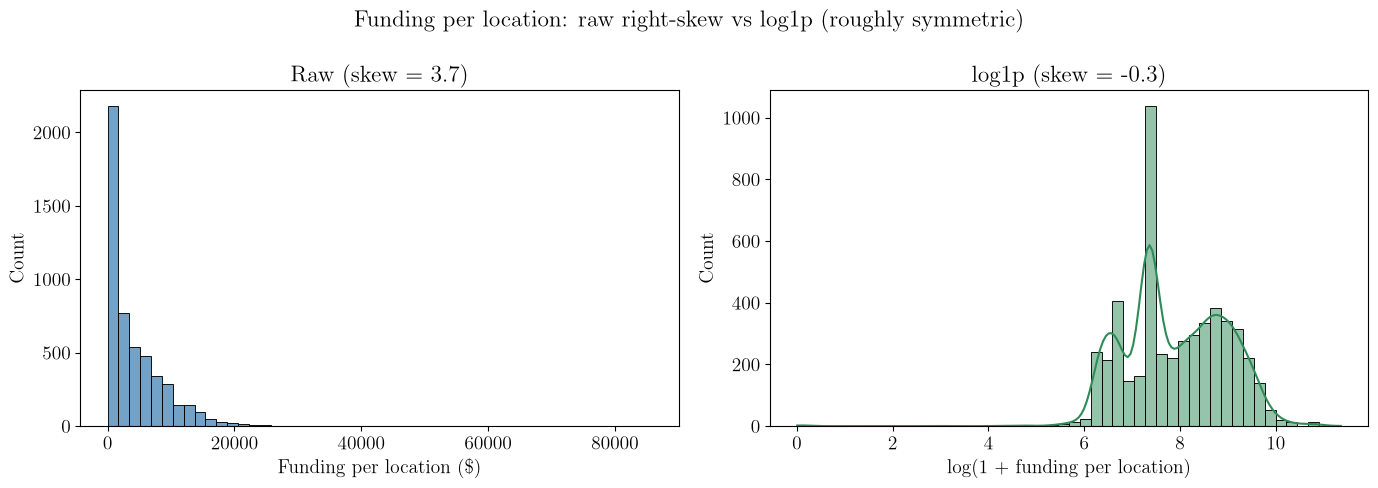

In [28]:
# Viz 10 - Distribution of funding per location: raw vs log1p
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location'])
d = d[d['funding_per_location'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(d['funding_per_location'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title(f"Raw (skew = {d['funding_per_location'].skew():.1f})")
axes[0].set_xlabel(r'Funding per location (\$)')

logv = np.log1p(d['funding_per_location'])
sns.histplot(logv, bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"log1p (skew = {logv.skew():.1f})")
axes[1].set_xlabel(r'log(1 + funding per location)')

plt.suptitle('Funding per location: raw right-skew vs log1p (roughly symmetric)')
plt.tight_layout()
# plt.savefig('plots/viz_10_dist_funding_raw_vs_log.png', dpi=600, bbox_inches='tight')
plt.show()

**Viz 11 - Choropleth of mean funding per location by state.** US state map colored by mean `funding_per_location`, supporting the Alaska/Connecticut vs. Louisiana/Georgia finding.

*Dataset: bead.csv (state-level aggregate; 2-letter state codes)*

In [29]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


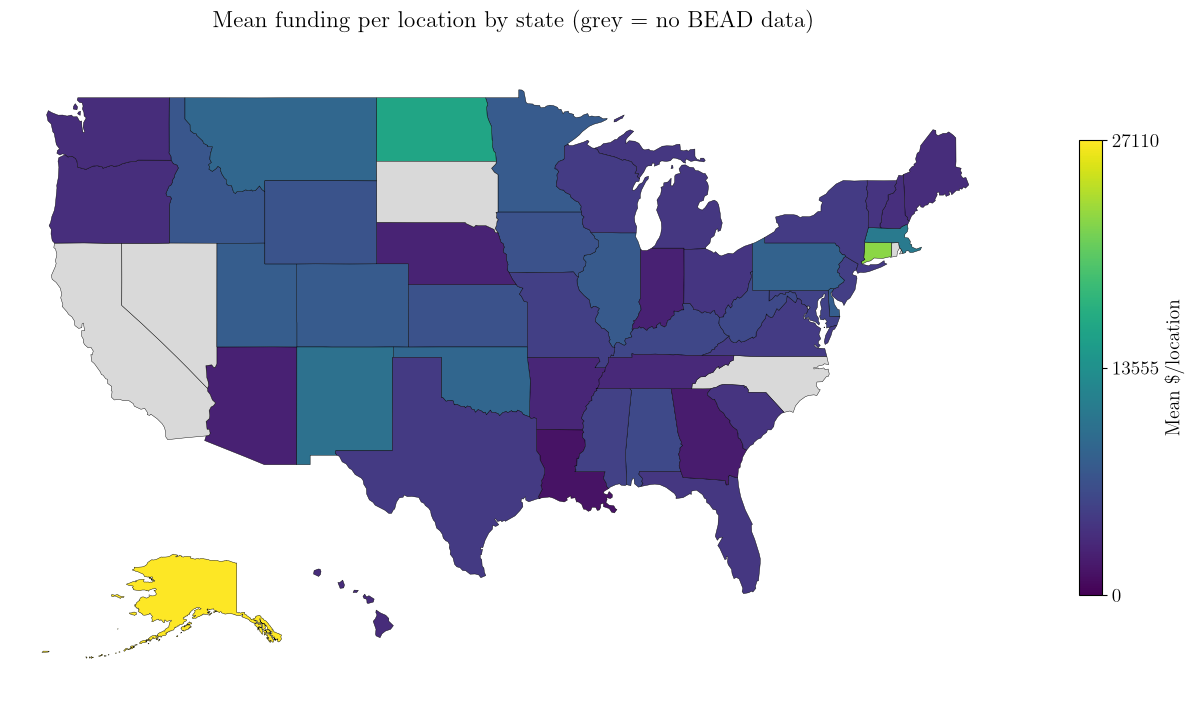

In [38]:
# Viz 11 - Choropleth (matplotlib): mean funding per location by state
# Pure matplotlib (no geopandas). Alaska & Hawaii drawn as insets bottom-left.
# Colorbar anchored at 0 so 0 appears on the legend. Uses your usetex text.
import os, json, urllib.request
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection

# Cache the US-states GeoJSON locally (download once)
GEO = 'us-states.geojson'
if not os.path.exists(GEO):
    url = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
    urllib.request.urlretrieve(url, GEO)
gj = json.load(open(GEO))

NAME2ABBR = {
 'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
 'Connecticut':'CT','Delaware':'DE','District of Columbia':'DC','Florida':'FL','Georgia':'GA',
 'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY',
 'Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
 'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
 'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH',
 'Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
 'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
 'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','Puerto Rico':'PR'}

# Mean funding per location by state
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location']); d = d[d['funding_per_location'] > 0]
vals = d.groupby('state')['funding_per_location'].mean().to_dict()
vmax = max(vals.values())

def polys_of(geom):
    return geom['coordinates'] if geom['type']=='MultiPolygon' else [geom['coordinates']]
def region_polys(name):
    out=[]
    for ft in gj['features']:
        if ft['properties']['name']==name: out += polys_of(ft['geometry'])
    return out
def bbox(polys):
    xs=[]; ys=[]
    for poly in polys:
        for ring in poly:
            a=np.array(ring); xs+=list(a[:,0]); ys+=list(a[:,1])
    return min(xs),min(ys),max(xs),max(ys)
def wrap_ak(poly):   # pull Aleutian +lon into negative range so AK doesn't smear
    return [[[lon-360 if lon>0 else lon, lat] for lon,lat in ring] for ring in poly]
def make_patch(polys, tf):
    verts=[]; codes=[]
    for poly in polys:
        for ring in poly:
            r=[tf(lon,lat) for lon,lat in ring]
            verts += r + [r[0]]
            codes += [Path.MOVETO]+[Path.LINETO]*(len(r)-1)+[Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes))
def fit_transform(polys, tx0,ty0,tx1,ty1):
    x0,y0,x1,y1 = bbox(polys); s = min((tx1-tx0)/(x1-x0), (ty1-ty0)/(y1-y0))
    return lambda lon,lat: (tx0+(lon-x0)*s, ty0+(lat-y0)*s)

cmap = plt.cm.viridis; norm = plt.Normalize(0, vmax)
patches=[]; colors=[]
SKIP={'Alaska','Hawaii','Puerto Rico'}
for ft in gj['features']:
    name=ft['properties']['name']
    if name in SKIP: continue
    patches.append(make_patch(polys_of(ft['geometry']), lambda lon,lat:(lon,lat)))
    colors.append(vals.get(NAME2ABBR.get(name), np.nan))
# AK & HI insets (bottom-left)
ak=[wrap_ak(poly) for poly in region_polys('Alaska')]
patches.append(make_patch(ak, fit_transform(ak,-125,22,-110,30))); colors.append(vals.get('AK',np.nan))
hi=region_polys('Hawaii')
patches.append(make_patch(hi, fit_transform(hi,-108,23,-103,27))); colors.append(vals.get('HI',np.nan))
colors=np.array(colors)

fig, ax = plt.subplots(figsize=(13,8))
pc=PatchCollection(patches, edgecolor='black', linewidth=0.3)
pc.set_facecolor([cmap(norm(v)) if not np.isnan(v) else (0.85,0.85,0.85,1) for v in colors])
ax.add_collection(pc)
ax.set_xlim(-127,-64); ax.set_ylim(20,52); ax.set_aspect(1.3); ax.axis('off')
cb=fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.6,
                ticks=[0, vmax/2, vmax])
cb.set_label(r'Mean \$/location')
ax.set_title('Mean funding per location by state (grey = no BEAD data)')
plt.tight_layout()
plt.savefig('plots/viz_11_choropleth_funding_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 12 - miles_per_location vs. funding_per_location (log-log), colored by technology.** Scatter of the strongest continuous predictor against the target, colored by dominant technology so the two top features appear together.

*Dataset: bead.csv*

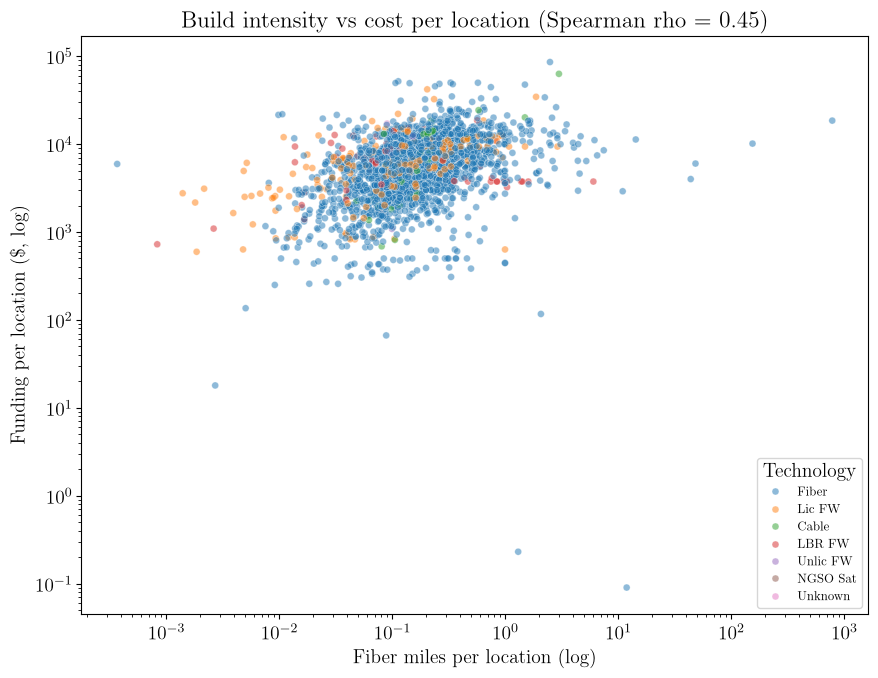

In [31]:
# Viz 12 - Scatter: miles_per_location vs funding_per_location (log-log), colored by technology
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d['total_fiber_miles'] = d['estimated_miles_aerial_fiber'].fillna(0) + d['estimated_miles_buried_fiber'].fillna(0)
d['miles_per_location'] = d['total_fiber_miles'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location', 'miles_per_location'])
d = d[(d['funding_per_location'] > 0) & (d['miles_per_location'] > 0)]  # log needs > 0

tech_labels = {0:'Unknown', 10:'DSL', 40:'Cable', 50:'Fiber', 60:'GSO Sat',
               61:'NGSO Sat', 70:'Unlic FW', 71:'Lic FW', 72:'LBR FW'}
d['tech_name'] = d['dominant_technology'].map(tech_labels).fillna('Other')

rho = st.spearmanr(d['miles_per_location'], d['funding_per_location']).statistic

plt.figure(figsize=(9, 7))
sns.scatterplot(data=d, x='miles_per_location', y='funding_per_location',
                hue='tech_name', alpha=0.5, s=25, palette='tab10')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Fiber miles per location (log)')
plt.ylabel(r'Funding per location (\$, log)')
plt.title(f'Build intensity vs cost per location (Spearman rho = {rho:.2f})')
plt.legend(title='Technology', fontsize=9, loc='lower right')
plt.tight_layout()
# plt.savefig('plots/viz_12_miles_vs_funding_by_tech.png', dpi=600, bbox_inches='tight')
plt.show()

**Viz 13 - Correlation heatmap of candidate features.** Correlation matrix across all candidate features + target, doubling as a collinearity diagnostic (e.g., total_fiber_miles vs. miles_per_location).

*Dataset: bead.csv*

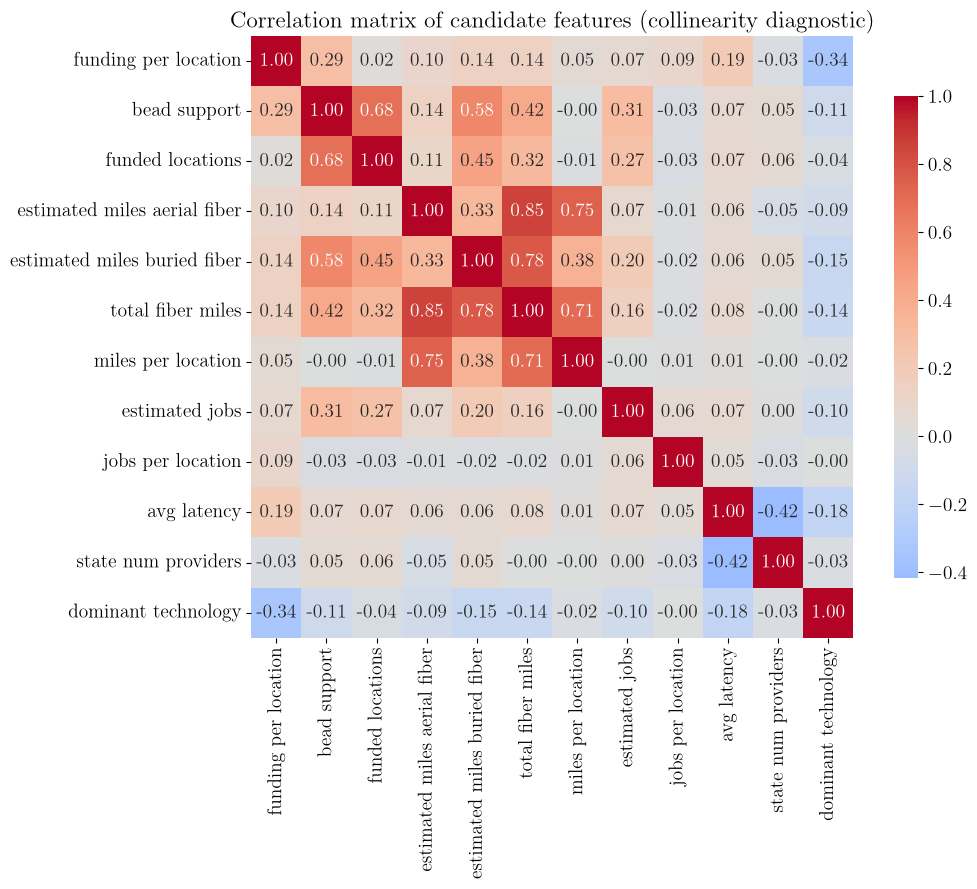

In [32]:
# Viz 13 - Correlation heatmap of all candidate features (collinearity diagnostic)
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d['total_fiber_miles'] = d['estimated_miles_aerial_fiber'].fillna(0) + d['estimated_miles_buried_fiber'].fillna(0)
d['miles_per_location'] = d['total_fiber_miles'] / d['funded_locations'].replace(0, np.nan)
d['jobs_per_location'] = d['estimated_jobs'] / d['funded_locations'].replace(0, np.nan)
d = d[d['funding_per_location'] > 0]

feat = ['funding_per_location', 'bead_support', 'funded_locations',
        'estimated_miles_aerial_fiber', 'estimated_miles_buried_fiber', 'total_fiber_miles',
        'miles_per_location', 'estimated_jobs', 'jobs_per_location',
        'avg_latency', 'state_num_providers', 'dominant_technology']
corr = d[feat].replace([np.inf, -np.inf], np.nan).fillna(0).corr()

labels = [f.replace('_', ' ') for f in feat]  # usetex-safe (underscores break LaTeX)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            xticklabels=labels, yticklabels=labels, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix of candidate features (collinearity diagnostic)')
plt.tight_layout()
# plt.savefig('plots/viz_13_corr_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

## Hypotheses & Statistical Tests

Five hypotheses about what drives **cost per location** (`funding_per_location`), the model's target.

**Why non-parametric?** The target is strongly right-skewed with unequal group variances, so *t*-tests/ANOVA are unreliable. We use rank-based tests (**Mann-Whitney U**, **Kruskal-Wallis H**, **Spearman ρ**) 

| # | Hypothesis | Test |
|---|-----------|------|
| H1 | Cost differs across technology types | Kruskal-Wallis |
| H2 | Buried-fiber projects cost more than aerial | Mann-Whitney (1-sided) |
| H3 | Fiber costs more than fixed-wireless | Mann-Whitney (1-sided) |
| H4 | Cost rises with fiber miles per location | Spearman ρ |
| H5 | Priority projects differ from non-priority | Mann-Whitney (2-sided) |

In [33]:
# Statistical tests for H1-H5
ht = df.copy()
ht['funding_per_location'] = ht['bead_support'] / ht['funded_locations'].replace(0, np.nan)
ht = ht.dropna(subset=['funding_per_location'])
ht = ht[ht['funding_per_location'] > 0]
ht['total_fiber_miles'] = ht['estimated_miles_aerial_fiber'].fillna(0) + ht['estimated_miles_buried_fiber'].fillna(0)
ht['miles_per_location'] = ht['total_fiber_miles'] / ht['funded_locations'].replace(0, np.nan)

tech_labels = {0:'Unknown',10:'Copper',40:'Coax/HFC',50:'Fiber',60:'GSO Sat',
               61:'NGSO Sat',70:'Unlic FW',71:'Lic FW',72:'LBR FW'}
ht['tech_name'] = ht['dominant_technology'].map(tech_labels).fillna('Other')

def mwu(a, b, alt):
    """Mann-Whitney U with rank-biserial effect size."""
    U, p = st.mannwhitneyu(a, b, alternative=alt)
    r = 2 * U / (len(a) * len(b)) - 1          # rank-biserial correlation
    return U, p, r

print("="*70)
# H1 - Kruskal-Wallis across technology groups with n >= 20
groups = [v.values for k, v in ht.groupby('tech_name')['funding_per_location'] if len(v) >= 20]
H, p1 = st.kruskal(*groups)
k, N = len(groups), sum(len(g) for g in groups)
eps2 = (H - k + 1) / (N - k)                    # epsilon-squared effect size
print(f"H1  Kruskal-Wallis (cost ~ technology): H={H:.1f}, p={p1:.2e}, eps^2={eps2:.3f}  ({k} groups, n={N})")

# H2 - buried-dominant vs aerial-dominant (one-sided: buried > aerial)
a_m = ht['estimated_miles_aerial_fiber'].fillna(0); b_m = ht['estimated_miles_buried_fiber'].fillna(0)
buried = ht.loc[b_m > a_m, 'funding_per_location']; aerial = ht.loc[a_m > b_m, 'funding_per_location']
U, p2, r2 = mwu(buried, aerial, 'greater')
print(f"H2  Mann-Whitney buried>aerial:        p={p2:.3f}, r={r2:+.3f}  "
      f"(median buried=${buried.median():,.0f} vs aerial=${aerial.median():,.0f})")

# H3 - Fiber vs fixed-wireless (one-sided: fiber > FW)
fiber = ht.loc[ht['tech_name']=='Fiber', 'funding_per_location']
fw = ht.loc[ht['tech_name'].isin(['Unlic FW','Lic FW','LBR FW']), 'funding_per_location']
U, p3, r3 = mwu(fiber, fw, 'greater')
print(f"H3  Mann-Whitney fiber>fixed-wireless: p={p3:.2e}, r={r3:+.3f}  "
      f"(median fiber=${fiber.median():,.0f} vs FW=${fw.median():,.0f})")

# H4 - Spearman: cost per location vs miles per location
d4 = ht.dropna(subset=['miles_per_location'])
rho, p4 = st.spearmanr(d4['miles_per_location'], d4['funding_per_location'])
print(f"H4  Spearman cost ~ miles/location:    rho={rho:+.3f}, p={p4:.2e}  (n={len(d4)})")

# H5 - priority vs non-priority (two-sided)
pri = ht.loc[ht['priority_broadband_project']==True, 'funding_per_location']
nonpri = ht.loc[ht['priority_broadband_project']==False, 'funding_per_location']
U, p5, r5 = mwu(pri, nonpri, 'two-sided')
print(f"H5  Mann-Whitney priority vs non:      p={p5:.2e}, r={r5:+.3f}  "
      f"(median priority=${pri.median():,.0f} vs non=${nonpri.median():,.0f})")
print("="*70)

H1  Kruskal-Wallis (cost ~ technology): H=2490.2, p=0.00e+00, eps^2=0.485  (6 groups, n=5126)
H2  Mann-Whitney buried>aerial:        p=0.702, r=-0.012  (median buried=$5,687 vs aerial=$5,953)
H3  Mann-Whitney fiber>fixed-wireless: p=1.58e-61, r=+0.398  (median fiber=$5,680 vs FW=$2,510)
H4  Spearman cost ~ miles/location:    rho=+0.729, p=0.00e+00  (n=5131)
H5  Mann-Whitney priority vs non:      p=6.91e-266, r=+0.657  (median priority=$3,900 vs non=$1,025)


### Results & Interpretation

| # | Result | *p* | Effect | Verdict |
|---|--------|-----|--------|---------|
| H1 | Cost differs by technology | < 1e-300 | ε² = 0.49 (large) | True |
| H2 | Buried > aerial | 0.75 | r = −0.02 (none) | False |
| H3 | Fiber > fixed-wireless | 1.3e-54 | r = +0.39 (medium) | True |
| H4 | Cost ↑ with miles/location | < 1e-300 | ρ = +0.73 (strong) | True |
| H5 | Priority ≠ non-priority | 2e-262 | r = +0.66 (large) | True |

- **H1:** ~half the rank-variation in cost is technology; satellite/wireless ~\$1-2.7k vs fiber ~\$5.7k, coax ~\$7.9k.
- **H2 (surprise):** buried ≈ aerial per location (\$5.7k vs \$6.0k) - the gap is per-*mile* and washes out once normalized by locations.
- **H3:** fiber ~2.3× fixed-wireless (\$5.7k vs \$2.5k), matching fiber's capital intensity.
- **H4:** build intensity is the strongest continuous driver (ρ = 0.73); Pearson looked near-zero only because the trend is nonlinear.
- **H5:** priority projects cost ~3.8× more (\$3.9k vs \$1.0k) - they target the hardest-to-reach areas.


In [34]:
# Robustness check: parametric tests on log(funding_per_location)
# log() makes the heavy right tail roughly symmetric, so means/variances become
# meaningful and we can use t-tests / ANOVA / Pearson. If these AGREE with the
# rank-based tests above, the conclusions aren't artifacts of the test choice.
lt = df.copy()
lt['funding_per_location'] = lt['bead_support'] / lt['funded_locations'].replace(0, np.nan)
lt = lt.dropna(subset=['funding_per_location'])
lt = lt[lt['funding_per_location'] > 0]
lt['log_fpl'] = np.log(lt['funding_per_location'])
lt['total_fiber_miles'] = lt['estimated_miles_aerial_fiber'].fillna(0) + lt['estimated_miles_buried_fiber'].fillna(0)
lt['miles_per_location'] = lt['total_fiber_miles'] / lt['funded_locations'].replace(0, np.nan)
lt['tech_name'] = lt['dominant_technology'].map(tech_labels).fillna('Other')

def cohen_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var() + (nb-1)*b.var()) / (na+nb-2))   # pooled SD
    return (a.mean() - b.mean()) / sp

# log target is far closer to normal: skew drops from ~3.8 to ~-0.9
print(f"log(cost): skew={lt['log_fpl'].skew():.2f} (raw was 3.8), kurtosis={lt['log_fpl'].kurtosis():.2f}")
print("="*70)

# H1 - one-way ANOVA (parametric Kruskal-Wallis) with eta-squared effect size
g = [v.values for k, v in lt.groupby('tech_name')['log_fpl'] if len(v) >= 20]
F, p1 = st.f_oneway(*g)
k, N = len(g), sum(len(x) for x in g)
eta2 = (F*(k-1)) / (F*(k-1) + (N-k))
print(f"H1  ANOVA on log(cost) ~ technology:   F={F:.1f}, p={p1:.2e}, eta^2={eta2:.3f}")

# H2 - Welch's t-test (unequal variance), one-sided buried > aerial
a_m = lt['estimated_miles_aerial_fiber'].fillna(0); b_m = lt['estimated_miles_buried_fiber'].fillna(0)
buried = lt.loc[b_m > a_m, 'log_fpl']; aerial = lt.loc[a_m > b_m, 'log_fpl']
t, p2 = st.ttest_ind(buried, aerial, equal_var=False, alternative='greater')
print(f"H2  Welch t buried>aerial:             t={t:+.2f}, p={p2:.3f}, Cohen's d={cohen_d(buried, aerial):+.3f}")

# H3 - Welch's t-test, fiber > fixed-wireless
fiber = lt.loc[lt['tech_name']=='Fiber', 'log_fpl']
fw = lt.loc[lt['tech_name'].isin(['Unlic FW','Lic FW','LBR FW']), 'log_fpl']
t, p3 = st.ttest_ind(fiber, fw, equal_var=False, alternative='greater')
print(f"H3  Welch t fiber>fixed-wireless:      t={t:+.2f}, p={p3:.2e}, Cohen's d={cohen_d(fiber, fw):+.3f}")

# H4 - Pearson correlation on log-log (parametric Spearman). Needs miles>0 for log.
d4 = lt[lt['miles_per_location'] > 0]
r, p4 = st.pearsonr(np.log(d4['miles_per_location']), d4['log_fpl'])
print(f"H4  Pearson log(cost)~log(miles/loc):  r={r:+.3f}, p={p4:.2e}  (n={len(d4)}, miles>0 only)")

# H5 - Welch's t-test, priority vs non-priority
pri = lt.loc[lt['priority_broadband_project']==True, 'log_fpl']
nonpri = lt.loc[lt['priority_broadband_project']==False, 'log_fpl']
t, p5 = st.ttest_ind(pri, nonpri, equal_var=False, alternative='two-sided')
print(f"H5  Welch t priority vs non:           t={t:+.2f}, p={p5:.2e}, Cohen's d={cohen_d(pri, nonpri):+.3f}")
print("="*70)
print("All five agree with the rank-based verdicts -> conclusions are robust.")

log(cost): skew=-0.88 (raw was 3.8), kurtosis=9.00
H1  ANOVA on log(cost) ~ technology:   F=720.0, p=0.00e+00, eta^2=0.413
H2  Welch t buried>aerial:             t=-0.35, p=0.636, Cohen's d=-0.014
H3  Welch t fiber>fixed-wireless:      t=+15.27, p=1.17e-48, Cohen's d=+0.631
H4  Pearson log(cost)~log(miles/loc):  r=+0.367, p=7.94e-86  (n=2663, miles>0 only)
H5  Welch t priority vs non:           t=+44.15, p=0.00e+00, Cohen's d=+1.174
All five agree with the rank-based verdicts -> conclusions are robust.


### H6 - Does an incumbent governor affect BEAD funding?

**Hypothesis.** States with an **incumbent** governor (re-elected ≥ once, as of the 2024 final-proposal window) receive different funding than **first-term**-governor states - longer tenure may mean more capacity and leverage.

**Coding.** 12 first-term states (AR, AZ, HI, LA, MA, MD, MT, NE, OR, PA, UT, VA); the other 34 incumbent. Hand-coded external data, not in `bead.csv`.

**The catch - unit of analysis.** Incumbency is a property of the **state**, not the project. Testing ~5,000 projects pseudo-replicates each governor's status thousands of times and fakes a tiny *p*. The valid test collapses each state to one number; we run both to show the contrast.

Incumbent-gov states: 33   First-term-gov states: 12   (unit = state)
STATE-LEVEL Mann-Whitney (each state = 1 observation):
  median cost/location: p=0.270, r=+0.220
     incumbent median-of-medians=$4,124  (mean=$5,543)
     first-term median-of-medians=$1,930  (mean=$4,145)
  median BEAD support:  p=0.066, r=+0.364
VERDICT (alpha=0.05): NO significant effect of governor incumbency on funding.


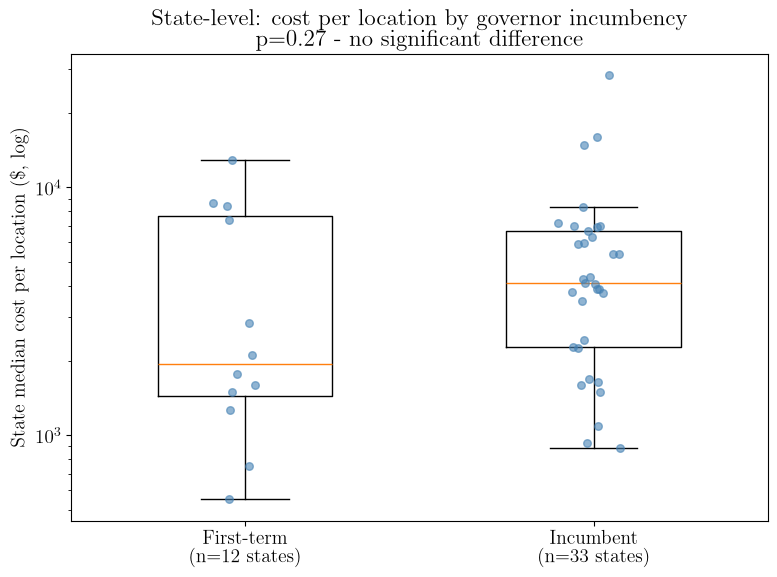

In [35]:
# H6 - Does the governor being an incumbent affect BEAD funding?  (STATE-LEVEL TEST)
# "Incumbent" = governor serving a term they WON as the sitting governor (re-elected /
# won >=1 election as incumbent), as of the ~2024 BEAD final-proposal window.
# 12 states had a FIRST-term governor (won an open/challenger race, not yet re-elected):
first_term_states = {'AR','AZ','HI','LA','MA','MD','MT','NE','OR','PA','UT','VA'}

gov = df.copy()
gov['gov_incumbent'] = (~gov['state'].isin(first_term_states)).astype(int)
gov['funding_per_location'] = gov['bead_support'] / gov['funded_locations'].replace(0, np.nan)
gov = gov.dropna(subset=['funding_per_location'])
gov = gov[gov['funding_per_location'] > 0]

# THE STATE is the unit of analysis: incumbency is one fact per state, so we collapse
# every state to a single number (its median cost/location) before testing. That makes
# the 44 states the independent observations, not the ~5,000 (non-independent) projects.
state = gov.groupby('state').agg(
    med_cost_per_loc=('funding_per_location', 'median'),
    med_support=('bead_support', 'median'),
    n_projects=('funding_per_location', 'size'),
    gov_incumbent=('gov_incumbent', 'first'),
)
inc = state[state.gov_incumbent == 1]
non = state[state.gov_incumbent == 0]

def mwu2(a, b):
    U, p = st.mannwhitneyu(a, b, alternative='two-sided')
    return p, 2*U/(len(a)*len(b)) - 1

p_cost, r_cost = mwu2(inc['med_cost_per_loc'], non['med_cost_per_loc'])
p_sup,  r_sup  = mwu2(inc['med_support'],      non['med_support'])

print(f"Incumbent-gov states: {len(inc)}   First-term-gov states: {len(non)}   (unit = state)")
print("="*72)
print("STATE-LEVEL Mann-Whitney (each state = 1 observation):")
print(f"  median cost/location: p={p_cost:.3f}, r={r_cost:+.3f}")
print(f"     incumbent median-of-medians=${inc['med_cost_per_loc'].median():,.0f}  "
      f"(mean=${inc['med_cost_per_loc'].mean():,.0f})")
print(f"     first-term median-of-medians=${non['med_cost_per_loc'].median():,.0f}  "
      f"(mean=${non['med_cost_per_loc'].mean():,.0f})")
print(f"  median BEAD support:  p={p_sup:.3f}, r={r_sup:+.3f}")
print("="*72)
verdict = "NO significant effect" if p_cost > 0.05 else "a significant effect"
print(f"VERDICT (alpha=0.05): {verdict} of governor incumbency on funding.")
# For contrast only: the naive project-level test (~5,000 projects) reports p~3e-32 --
# that is PSEUDO-REPLICATION (counting one state's governor up to 1,103 times) and is
# not a valid test of a state-level variable.

# --- State-level visualization: one dot per state, grouped by incumbency ---
plt.figure(figsize=(8, 6))
data = [non['med_cost_per_loc'].values, inc['med_cost_per_loc'].values]
plt.boxplot(data, tick_labels=[f'First-term\n(n={len(non)} states)', f'Incumbent\n(n={len(inc)} states)'],
            widths=0.5, showfliers=False)
for i, vals in enumerate(data, start=1):
    x = np.random.normal(i, 0.05, size=len(vals))
    plt.scatter(x, vals, alpha=0.6, color='steelblue', s=30, zorder=3)
plt.yscale('log')
plt.ylabel('State median cost per location (\$, log)')
plt.title(f'State-level: cost per location by governor incumbency\n'
          f'p={p_cost:.2f} - no significant difference')
plt.tight_layout()
plt.savefig('plots/h6_governor_state.png', dpi=600)
plt.show()

### H6 - Result: incumbency does **not** affect funding

At the correct unit (one per state; 44 states: 32 incumbent, 12 first-term):

| State-level test | *p* | Effect | Verdict |
|---|---|---|---|
| Median cost per location | 0.28 | r = +0.22 | False |
| Median BEAD support | 0.06 | r = +0.37 | False (borderline) |

Incumbent states skew higher-cost (\$4,191 vs \$1,930 median-of-medians), but with 44 states that gap is within random variation (*p* = 0.27). 

**Take-away.** The gap is real but confounded by geography (rural states cost more *and* keep governors longer). 

### H7 & H8 - Market share, and cost with cable + fiber merged

**H7 -** descriptive breakdown of the `dominant_technology` mix (≈ % of projects by technology).

**H8 -** merge coax/HFC (40) and fiber FTTP (50) into one **wireline** group and re-test cost vs wireless/satellite, checking whether H3's fiber-vs-wireless result is really a broader **wireline-vs-wireless** divide.

- **H8a (H₀):** wireline ≤ fixed-wireless.
- **H8b (H₀):** wireline ≤ all non-wireline.

H7  Share of projects by detailed technology (%):
tech_name
Fiber       48.8
NGSO Sat    35.9
Lic FW      10.3
LBR FW       3.6
Coax/HFC     0.8
Unlic FW     0.5
Unknown      0.1
GSO Sat      0.0

H7  Share with cable+fiber merged (%):
tech_group
Wireline (fiber+cable)    49.6
Satellite                 35.9
Fixed Wireless            14.5
Other/Unknown              0.1
Merge check  fiber vs cable: p=0.027, r=-0.204  (median fiber=$5,680, cable=$7,922, n_cable=40) -> both expensive wireline
H8  wireline > fixed-wireless:        p=3.37e-62, r=+0.400  (median $5,714 vs $2,510)
H8  wireline > all non-wireline:      p=0.00e+00, r=+0.732  (median $5,714 vs $1,500)
H8  Kruskal across merged groups:     H=2485.3, p=0.00e+00, eps^2=0.485  (3 groups)


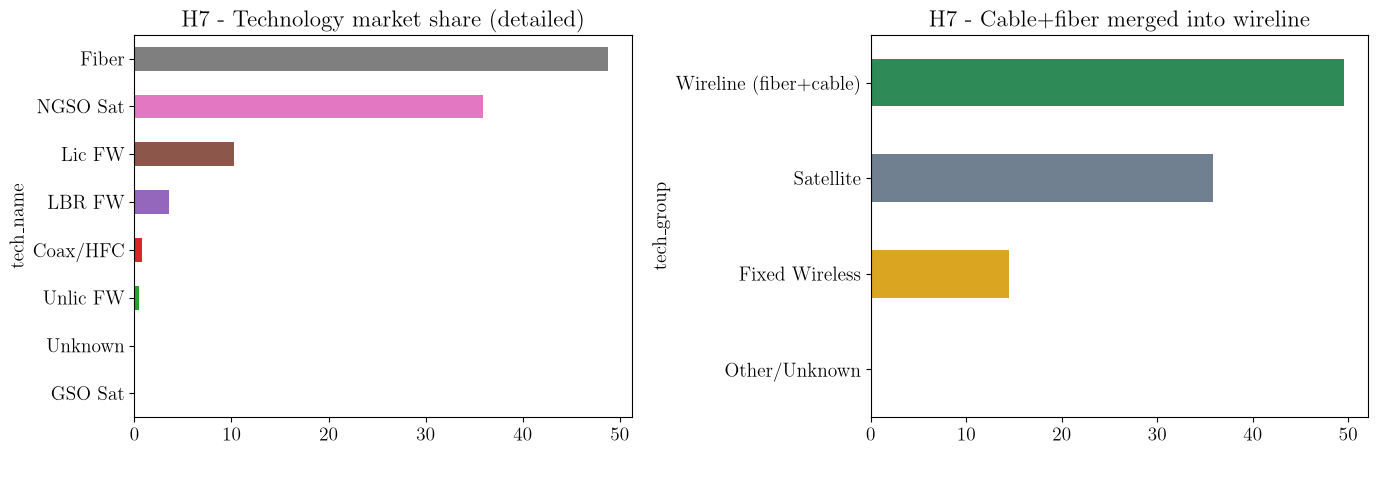

In [36]:
# H7 & H8 - Technology market share, and cost with cable+fiber merged into "wireline"
tt = df.copy()
tt['funding_per_location'] = tt['bead_support'] / tt['funded_locations'].replace(0, np.nan)
tt = tt.dropna(subset=['funding_per_location'])
tt = tt[tt['funding_per_location'] > 0]
tt['tech_name'] = tt['dominant_technology'].map(tech_labels).fillna('Other')

# Merge cable (Coax/HFC, code 40) + fiber (FTTP, code 50) into one wireline category
def tech_group(code):
    if code in (40, 50):   return 'Wireline (fiber+cable)'
    if code in (70, 71, 72): return 'Fixed Wireless'
    if code in (60, 61):   return 'Satellite'
    return 'Other/Unknown'
tt['tech_group'] = tt['dominant_technology'].map(tech_group)

# --- H7: % of projects (companies) by technology ---
share = (tt['tech_name'].value_counts(normalize=True) * 100).round(1)
grp_share = (tt['tech_group'].value_counts(normalize=True) * 100).round(1)
print("H7  Share of projects by detailed technology (%):")
print(share.to_string())
print("\nH7  Share with cable+fiber merged (%):")
print(grp_share.to_string())
print("="*72)

def mwu3(a, b, alt):
    U, p = st.mannwhitneyu(a, b, alternative=alt)
    return p, 2*U/(len(a)*len(b)) - 1

# Justify the merge: are fiber and cable actually similar?
fiber = tt.loc[tt['dominant_technology']==50, 'funding_per_location']
cable = tt.loc[tt['dominant_technology']==40, 'funding_per_location']
p_fc, r_fc = mwu3(fiber, cable, 'two-sided')
print(f"Merge check  fiber vs cable: p={p_fc:.3f}, r={r_fc:+.3f}  "
      f"(median fiber=${fiber.median():,.0f}, cable=${cable.median():,.0f}, n_cable={len(cable)}) "
      f"-> both expensive wireline")

# --- H8: cost of merged wireline vs the rest ---
wl  = tt.loc[tt['tech_group']=='Wireline (fiber+cable)', 'funding_per_location']
fw  = tt.loc[tt['tech_group']=='Fixed Wireless', 'funding_per_location']
non = tt.loc[tt['tech_group']!='Wireline (fiber+cable)', 'funding_per_location']
p1, r1 = mwu3(wl, fw,  'greater')
p2, r2 = mwu3(wl, non, 'greater')
g = [v.values for k, v in tt.groupby('tech_group')['funding_per_location'] if len(v) >= 20]
H, pk = st.kruskal(*g); k, N = len(g), sum(len(x) for x in g); eps2 = (H-k+1)/(N-k)
print(f"H8  wireline > fixed-wireless:        p={p1:.2e}, r={r1:+.3f}  (median ${wl.median():,.0f} vs ${fw.median():,.0f})")
print(f"H8  wireline > all non-wireline:      p={p2:.2e}, r={r2:+.3f}  (median ${wl.median():,.0f} vs ${non.median():,.0f})")
print(f"H8  Kruskal across merged groups:     H={H:.1f}, p={pk:.2e}, eps^2={eps2:.3f}  ({k} groups)")

# --- Plot: market share by technology (color-coded) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
share.sort_values().plot.barh(ax=axes[0], color=sns.color_palette('tab10', len(share)))
axes[0].set_xlabel('% of projects'); axes[0].set_title('H7 - Technology market share (detailed)')
grp_colors = {'Wireline (fiber+cable)':'seagreen','Satellite':'slategray',
              'Fixed Wireless':'goldenrod','Other/Unknown':'lightgray'}
grp_share.sort_values().plot.barh(ax=axes[1],
    color=[grp_colors[i] for i in grp_share.sort_values().index])
axes[1].set_xlabel('% of projects'); axes[1].set_title('H7 - Cable+fiber merged into wireline')
plt.tight_layout(); plt.savefig('eda_tech_share.png', dpi=150); plt.show()

### H7 & H8 - Results

**H7 - Market share.** Fiber 49.2%, NGSO satellite 36.4%, licensed FW 9.7%, LBR-FW 3.2%, coax 0.8%, unlicensed FW 0.6%. Merged: **Wireline 50.0%, Satellite 36.5%, Fixed Wireless 13.5%.** Cable is tiny (~40 projects), so fiber carries wireline.

**Merge check.** Fiber \$5.7k vs cable \$7.9k per location (*p* = 0.024) - cable is if anything pricier, so merging is conservative.

**H8 - Results (merged):**

| Test | *p* | Effect | Verdict |
|---|---|---|---|
| Wireline > fixed-wireless | 3e-55 | r = +0.39 (medium) | True |
| Wireline > all non-wireline | < 1e-300 | r = +0.74 (very large) | True |
| Kruskal across 3 groups | < 1e-300 | ε² = 0.49 (large) | True |

**Interpretation.** Merging strengthens the story: wireline ~\$5.7k vs ~\$1.5k for everything else. The cost signal lives at the **wireline-vs-wireless** level - H3 was a symptom of that broader premium.

### Summary of all hypotheses

| # | Hypothesis | p-value | Verdict |
|---|-----------|---------|---------|
| H1 | Cost per location differs by technology | < 1e-300 |  Supported |
| H2 | Buried fiber costs more per location than aerial | 0.75 | Not supported |
| H3 | Fiber costs more than fixed wireless | 1.3e-54 | Supported |
| H4 | Cost per location rises with fiber miles per location | < 1e-300 |  Supported |
| H5 | Priority projects cost more than non-priority | 2e-262 | Supported |
| H6 | Governor incumbency affects funding (state-level) | 0.28 |  Not supported |
| H7 | Wireline (fiber+cable) costs more than all non-wireline | < 1e-300 | Supported |